loding the data from previous notebook of the baslinfeature

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data/processed/datasets")

X_train = pd.read_parquet(DATA_DIR / "X_train_baseline.parquet")
y_train = pd.read_parquet(DATA_DIR / "y_train.parquet")["lithology"]

X_public = pd.read_parquet(DATA_DIR / "X_public_baseline.parquet")
y_public = pd.read_parquet(DATA_DIR / "y_public.parquet")["lithology"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_public:", X_public.shape)
print("y_public:", y_public.shape)

print("\nClasses:", sorted(y_train.unique()))
print("Number of classes:", y_train.nunique())

X_train: (1171557, 5)
y_train: (1171557,)
X_public: (136841, 5)
y_public: (136841,)

Classes: [np.float64(30000.0), np.float64(65000.0), np.float64(65030.0), np.float64(70000.0), np.float64(70032.0), np.float64(74000.0), np.float64(80000.0), np.float64(86000.0), np.float64(88000.0), np.float64(90000.0), np.float64(93000.0), np.float64(99000.0)]
Number of classes: 12


**our first model is random forest**

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)
import time

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

print("Training Random Forest...")

start = time.perf_counter()

rf_baseline.fit(X_train, y_train)

train_time = time.perf_counter() - start

print(f"Training time: {train_time:.2f} seconds")

Training Random Forest...
Training time: 73.68 seconds


**now evaluating this model on the 10 public well**

In [5]:
print("Predicting PUBLIC set...")

start = time.perf_counter()

y_public_pred = rf_baseline.predict(X_public)

prediction_time = time.perf_counter() - start

accuracy = accuracy_score(y_public, y_public_pred)
balanced_acc = balanced_accuracy_score(y_public, y_public_pred)
macro_f1 = f1_score(y_public, y_public_pred, average="macro")
weighted_f1 = f1_score(y_public, y_public_pred, average="weighted")

print(f"Prediction time: {prediction_time:.2f} seconds")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_public,
        y_public_pred,
        zero_division=0
    )
)

Predicting PUBLIC set...
Prediction time: 0.83 seconds
Accuracy:          0.5289
Balanced Accuracy: 0.4237
Macro F1:          0.2718
Weighted F1:       0.5922

Classification report:
              precision    recall  f1-score   support

     30000.0       0.74      0.71      0.72     24048
     65000.0       0.88      0.52      0.65     84030
     65030.0       0.29      0.38      0.33     17558
     70000.0       0.35      0.49      0.41      4798
     70032.0       0.35      0.18      0.24       625
     74000.0       0.00      0.01      0.00       416
     80000.0       0.08      0.36      0.13      3306
     86000.0       0.49      0.22      0.30       125
     88000.0       0.00      0.00      0.00         0
     90000.0       0.25      0.71      0.37       690
     93000.0       0.00      0.00      0.00         0
     99000.0       0.06      0.66      0.10      1245

    accuracy                           0.53    136841
   macro avg       0.29      0.35      0.27    136841
weigh

/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Metric | Public score |
|---|---:|
| Accuracy | **0.5289** |
| Balanced Accuracy | **0.4237** |
| Macro F1 | **0.2718** |
| Weighted F1 | **0.5922** |

**model is doing reasonably well on common lithologies:**
- Marl 80000: F1 0.13
- Sandstone 30000: F1 0.72
- Shale 65000: F1 0.65
- Sandstone/Shale 65030: F1 0.33
- Limestone 70000: F1 0.41

**But it struggles badly with rare classes:**
- Dolomite 74000: F1 ≈ 0
- Halite 88000: F1 = 0
- Basement 93000: F1 = 0
- Tuff 99000: F1 0.10



**confusion matrix**

In [7]:
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = sorted(y_train.unique())

cm = confusion_matrix(
    y_public,
    y_public_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print(cm_df)

NameError: name 'y_train' is not defined

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

ENGINEERED_FILE = "../data/processed/engineered_features.parquet"

df = pd.read_parquet(ENGINEERED_FILE)

print("Shape:", df.shape)
print("Wells:", df["WELL"].nunique())

Shape: (1430974, 46)
Wells: 118


In [6]:
BASELINE_FEATURES = [
    "GR",
    "RDEP_LOG10",
    "RMED_LOG10",
    "DTC",
    "RHOB"
]

ROLLING_FEATURES = [
    c for c in df.columns
    if "_ROLLMEAN_" in c or "_ROLLSTD_" in c
]

MISSING_FEATURES = [
    f"{feature}_MISSING"
    for feature in BASELINE_FEATURES
]

ENGINEERED_FEATURES = (
    BASELINE_FEATURES
    + ROLLING_FEATURES
    + ["RESISTIVITY_SEPARATION"]
    + MISSING_FEATURES
)

print("Baseline features:", len(BASELINE_FEATURES))
print("Rolling features:", len(ROLLING_FEATURES))
print("Resistivity feature:", 1)
print("Missingness features:", len(MISSING_FEATURES))
print("Total engineered features:", len(ENGINEERED_FEATURES))

missing = [f for f in ENGINEERED_FEATURES if f not in df.columns]
print("\nMissing columns:", missing)

NameError: name 'df' is not defined

just trying to reconstruc the official split just to check whether my feature selection works 

In [12]:
# Load the official well split
split_df = pd.read_csv("../data/splits/force2020_split.csv")

# Attach split to the engineered dataset
df = df.drop(columns=["SPLIT"], errors="ignore")

df = df.merge(
    split_df,
    on="WELL",
    how="left",
    validate="many_to_one"
)

print(df["SPLIT"].value_counts())
print()
print(df.groupby("SPLIT")["WELL"].nunique())

SPLIT
TRAIN         1171557
PUBLIC         136841
BLIND_TEST     122576
Name: count, dtype: int64

SPLIT
BLIND_TEST    10
PUBLIC        10
TRAIN         98
Name: WELL, dtype: int64


In [13]:
# Split the engineered dataset
train_eng = df[df["SPLIT"] == "TRAIN"].copy()
public_eng = df[df["SPLIT"] == "PUBLIC"].copy()
blind_eng = df[df["SPLIT"] == "BLIND_TEST"].copy()

# Training-only medians for all 41 engineered features
engineered_medians = train_eng[ENGINEERED_FEATURES].median()

print("Engineered features:", len(ENGINEERED_FEATURES))
print("Training rows:", len(train_eng))
print("Public rows:", len(public_eng))
print("Blind rows:", len(blind_eng))

print("\nFeatures with missing values before imputation:")
print(
    train_eng[ENGINEERED_FEATURES]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

Engineered features: 41
Training rows: 1171557
Public rows: 136841
Blind rows: 122576

Features with missing values before imputation:
RHOB                      161482
RHOB_ROLLMEAN_5           161479
RHOB_ROLLSTD_5            161479
RHOB_ROLLMEAN_9           161109
RHOB_ROLLSTD_9            161109
RHOB_ROLLSTD_21           160152
RHOB_ROLLMEAN_21          160152
DTC_ROLLMEAN_5             81470
DTC                        81470
DTC_ROLLSTD_5              81470
DTC_ROLLSTD_9              81238
DTC_ROLLMEAN_9             81238
DTC_ROLLSTD_21             80564
DTC_ROLLMEAN_21            80564
RESISTIVITY_SEPARATION     39693
dtype: int64


In [15]:
TARGET = "FORCE_2020_LITHOFACIES_LITHOLOGY"

print("Target:", TARGET)
print("Target exists:", TARGET in df.columns)

Target: FORCE_2020_LITHOFACIES_LITHOLOGY
Target exists: True


In [16]:
# Continuous engineered features only
CONTINUOUS_ENGINEERED_FEATURES = (
    BASELINE_FEATURES
    + ROLLING_FEATURES
    + ["RESISTIVITY_SEPARATION"]
)

# Apply TRAIN-derived medians to all splits
for feature in CONTINUOUS_ENGINEERED_FEATURES:
    median = engineered_medians[feature]

    train_eng[feature] = train_eng[feature].fillna(median)
    public_eng[feature] = public_eng[feature].fillna(median)
    blind_eng[feature] = blind_eng[feature].fillna(median)

# Construct X/y
X_train_eng = train_eng[ENGINEERED_FEATURES].copy()
y_train_eng = train_eng[TARGET].copy()

X_public_eng = public_eng[ENGINEERED_FEATURES].copy()
y_public_eng = public_eng[TARGET].copy()

X_blind_eng = blind_eng[ENGINEERED_FEATURES].copy()
y_blind_eng = blind_eng[TARGET].copy()

print("Remaining NaNs:")
print("TRAIN:", X_train_eng.isna().sum().sum())
print("PUBLIC:", X_public_eng.isna().sum().sum())
print("BLIND:", X_blind_eng.isna().sum().sum())

print("\nFeature shapes:")
print("TRAIN:", X_train_eng.shape)
print("PUBLIC:", X_public_eng.shape)
print("BLIND:", X_blind_eng.shape)

Remaining NaNs:
TRAIN: 0
PUBLIC: 0
BLIND: 0

Feature shapes:
TRAIN: (1171557, 41)
PUBLIC: (136841, 41)
BLIND: (122576, 41)


In [17]:
RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

now trsining

In [18]:
rf_engineered = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

print("Training Random Forest with 41 features...")

start = time.perf_counter()

rf_engineered.fit(X_train_eng, y_train_eng)

engineered_train_time = time.perf_counter() - start

print(f"Training time: {engineered_train_time:.2f} seconds")

Training Random Forest with 41 features...
Training time: 172.27 seconds


**seconf evalution**

In [19]:
start = time.perf_counter()

y_public_eng_pred = rf_engineered.predict(X_public_eng)

engineered_prediction_time = time.perf_counter() - start

eng_accuracy = accuracy_score(y_public_eng, y_public_eng_pred)
eng_balanced_acc = balanced_accuracy_score(y_public_eng, y_public_eng_pred)
eng_macro_f1 = f1_score(y_public_eng, y_public_eng_pred, average="macro")
eng_weighted_f1 = f1_score(y_public_eng, y_public_eng_pred, average="weighted")

print(f"Prediction time:    {engineered_prediction_time:.2f} s")
print(f"Accuracy:            {eng_accuracy:.4f}")
print(f"Balanced Accuracy:  {eng_balanced_acc:.4f}")
print(f"Macro F1:            {eng_macro_f1:.4f}")
print(f"Weighted F1:         {eng_weighted_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_public_eng,
        y_public_eng_pred,
        zero_division=0
    )
)

Prediction time:    0.98 s
Accuracy:            0.5740
Balanced Accuracy:  0.4458
Macro F1:            0.3042
Weighted F1:         0.6247

Classification report:
              precision    recall  f1-score   support

     30000.0       0.77      0.79      0.78     24048
     65000.0       0.89      0.56      0.69     84030
     65030.0       0.29      0.39      0.33     17558
     70000.0       0.38      0.60      0.47      4798
     70032.0       0.37      0.02      0.03       625
     74000.0       0.01      0.01      0.01       416
     80000.0       0.10      0.38      0.15      3306
     86000.0       0.75      0.12      0.21       125
     88000.0       0.00      0.00      0.00         0
     90000.0       0.41      0.87      0.56       690
     99000.0       0.07      0.73      0.13      1245

    accuracy                           0.57    136841
   macro avg       0.37      0.41      0.30    136841
weighted avg       0.74      0.57      0.62    136841



/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Metric | 5 features | 41 features | Change |
|---|---:|---:|---:|
| Accuracy | 0.5289 | **0.5740** | **+0.0451** |
| Balanced Accuracy | 0.4237 | **0.4458** | **+0.0221** |
| Macro F1 | 0.2718 | **0.3042** | **+0.0324** |
| Weighted F1 | 0.5922 | **0.6247** | **+0.0325** |

Several classes improved substantially:
- Sandstone: 0.72 → 0.78
- Shale: 0.65 → 0.69
- Limestone: 0.41 → 0.47
- Coal: 0.37 → 0.56

But some remain very difficult:
- Chalk: 0.24 → 0.03
- Dolomite: 0.00 → 0.01
- Marl: 0.13 → 0.15
- Tuff: 0.10 → 0.13

baseline + missingness indicators

5 baseline logs + 5 missing indicators = 10 features
We'll keep the exact same Random Forest configuration and evaluate only on PUBLIC

In [20]:
ABLATION_A_FEATURES = BASELINE_FEATURES + MISSING_FEATURES

X_train_A = train_eng[ABLATION_A_FEATURES].copy()
X_public_A = public_eng[ABLATION_A_FEATURES].copy()

print("Features:", len(ABLATION_A_FEATURES))
print(ABLATION_A_FEATURES)

rf_A = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

start = time.perf_counter()

rf_A.fit(X_train_A, y_train_eng)

y_public_A = rf_A.predict(X_public_A)

time_A = time.perf_counter() - start

A_accuracy = accuracy_score(y_public_eng, y_public_A)
A_balanced = balanced_accuracy_score(y_public_eng, y_public_A)
A_macro_f1 = f1_score(y_public_eng, y_public_A, average="macro")
A_weighted_f1 = f1_score(y_public_eng, y_public_A, average="weighted")

print("\nResults:")
print(f"Accuracy:           {A_accuracy:.4f}")
print(f"Balanced Accuracy:  {A_balanced:.4f}")
print(f"Macro F1:           {A_macro_f1:.4f}")
print(f"Weighted F1:        {A_weighted_f1:.4f}")
print(f"Train + prediction: {time_A:.2f} s")

Features: 10
['GR', 'RDEP_LOG10', 'RMED_LOG10', 'DTC', 'RHOB', 'GR_MISSING', 'RDEP_LOG10_MISSING', 'RMED_LOG10_MISSING', 'DTC_MISSING', 'RHOB_MISSING']

Results:
Accuracy:           0.5288
Balanced Accuracy:  0.4714
Macro F1:           0.3036
Weighted F1:        0.5948
Train + prediction: 67.99 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Metric | 5 baseline | + Missing indicators | Change |
|---|---:|---:|---:|
| Accuracy | 0.5289 | 0.5288 | −0.0001 |
| Balanced Accuracy | 0.4237 | **0.4714** | **+0.0477** |
| Macro F1 | 0.2718 | **0.3036** | **+0.0318** |
| Weighted F1 | 0.5922 | 0.5948 | +0.0026 |

Baseline + resistivity separation

In [21]:
ABLATION_B_FEATURES = BASELINE_FEATURES + ["RESISTIVITY_SEPARATION"]

X_train_B = train_eng[ABLATION_B_FEATURES].copy()
X_public_B = public_eng[ABLATION_B_FEATURES].copy()

rf_B = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

start = time.perf_counter()

rf_B.fit(X_train_B, y_train_eng)

y_public_B = rf_B.predict(X_public_B)

time_B = time.perf_counter() - start

B_accuracy = accuracy_score(y_public_eng, y_public_B)
B_balanced = balanced_accuracy_score(y_public_eng, y_public_B)
B_macro_f1 = f1_score(y_public_eng, y_public_B, average="macro")
B_weighted_f1 = f1_score(y_public_eng, y_public_B, average="weighted")

print("Features:", len(ABLATION_B_FEATURES))
print(f"Accuracy:           {B_accuracy:.4f}")
print(f"Balanced Accuracy:  {B_balanced:.4f}")
print(f"Macro F1:           {B_macro_f1:.4f}")
print(f"Weighted F1:        {B_weighted_f1:.4f}")
print(f"Train + prediction: {time_B:.2f} s")

Features: 6
Accuracy:           0.5410
Balanced Accuracy:  0.4389
Macro F1:           0.2827
Weighted F1:        0.6033
Train + prediction: 80.37 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Feature set | Features | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|---:|
| Baseline | 5 | 0.5289 | 0.4237 | 0.2718 | 0.5922 |
| + Missing indicators | 10 | 0.5288 | **0.4714** | **0.3036** | 0.5948 |
| + Resistivity separation | 6 | 0.5410 | 0.4389 | 0.2827 | **0.6033** |
| All engineered | 41 | **0.5740** | 0.4458 | **0.3042** | **0.6247** |

The two feature groups behave differently:
Missingness indicators
- Huge improvement in balanced accuracy: 0.4237 → 0.4714
- Macro-F1: 0.2718 → 0.3036
- Almost no accuracy improvement.

So missingness carries useful class-discriminative information.
Resistivity separation
- Accuracy: 0.5289 → 0.5410
- Macro-F1: 0.2718 → 0.2827

So it provides a smaller but consistent improvement.

**Let's isolate the rolling features:**
 Baseline + rolling statistics = 35 features

In [23]:
ABLATION_C_FEATURES = BASELINE_FEATURES + ROLLING_FEATURES

X_train_C = train_eng[ABLATION_C_FEATURES].copy()
X_public_C = public_eng[ABLATION_C_FEATURES].copy()

print("Number of features:", len(ABLATION_C_FEATURES))

rf_C = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

print("Training...")

start = time.perf_counter()

rf_C.fit(X_train_C, y_train_eng)

y_public_C = rf_C.predict(X_public_C)

time_C = time.perf_counter() - start

C_accuracy = accuracy_score(y_public_eng, y_public_C)
C_balanced = balanced_accuracy_score(y_public_eng, y_public_C)
C_macro_f1 = f1_score(y_public_eng, y_public_C, average="macro")
C_weighted_f1 = f1_score(y_public_eng, y_public_C, average="weighted")

print("\nResults:")
print(f"Accuracy:           {C_accuracy:.4f}")
print(f"Balanced Accuracy:  {C_balanced:.4f}")
print(f"Macro F1:           {C_macro_f1:.4f}")
print(f"Weighted F1:        {C_weighted_f1:.4f}")
print(f"Train + prediction: {time_C:.2f} s")

Number of features: 35
Training...

Results:
Accuracy:           0.5735
Balanced Accuracy:  0.4539
Macro F1:           0.3157
Weighted F1:        0.6229
Train + prediction: 158.04 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Feature set | Features | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|---:|
| Baseline | 5 | 0.5289 | 0.4237 | 0.2718 | 0.5922 |
| + Missing indicators | 10 | 0.5288 | **0.4714** | 0.3036 | 0.5948 |
| + Resistivity separation | 6 | 0.5410 | 0.4389 | 0.2827 | 0.6033 |
| **+ Rolling features** | **35** | **0.5735** | **0.4539** | **0.3157** | **0.6229** |
| All engineered | 41 | **0.5740** | 0.4458 | 0.3042 | **0.6247** |

**extra tree training on all the 46 features**

In [24]:
from sklearn.ensemble import ExtraTreesClassifier
import time

X_train = train_eng[ENGINEERED_FEATURES].copy()
X_public = public_eng[ENGINEERED_FEATURES].copy()

print("Number of features:", X_train.shape[1])

et = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

print("Training...")

start = time.perf_counter()

et.fit(X_train, y_train_eng)

y_public_et = et.predict(X_public)

time_et = time.perf_counter() - start

accuracy_et = accuracy_score(y_public_eng, y_public_et)
balanced_acc_et = balanced_accuracy_score(y_public_eng, y_public_et)
macro_f1_et = f1_score(y_public_eng, y_public_et, average="macro", zero_division=0)
weighted_f1_et = f1_score(y_public_eng, y_public_et, average="weighted", zero_division=0)

print("\nExtra Trees Results:")
print(f"Accuracy:           {accuracy_et:.4f}")
print(f"Balanced Accuracy:  {balanced_acc_et:.4f}")
print(f"Macro F1:           {macro_f1_et:.4f}")
print(f"Weighted F1:        {weighted_f1_et:.4f}")
print(f"Train + prediction: {time_et:.2f} s")

Number of features: 41
Training...

Extra Trees Results:
Accuracy:           0.5439
Balanced Accuracy:  0.5092
Macro F1:           0.3432
Weighted F1:        0.6081
Train + prediction: 37.71 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Model / Feature set | Features | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 | Time |
|---|---:|---:|---:|---:|---:|---:|
| RF — Baseline | 5 | 0.5289 | 0.4237 | 0.2718 | 0.5922 | — |
| RF — + Missing | 10 | 0.5288 | 0.4714 | 0.3036 | 0.5948 | 68s |
| RF — + Resistivity | 6 | 0.5410 | 0.4389 | 0.2827 | 0.6033 | 80s |
| RF — + Rolling | 35 | 0.5735 | 0.4539 | 0.3157 | 0.6229 | 158s |
| **RF — All engineered** | **41** | **0.5740** | **0.4458** | **0.3042** | **0.6247** | **172s** |
| **Extra Trees — All engineered** | **41** | **0.5439** | **0.5092** | **0.3432** | **0.6081** | **37.7s** |

**Extra Trees has lower overall accuracy than RF:**
54.39% vs 57.40%

But it has much better class-balanced performance:
Balanced Accuracy: 50.92% vs 44.58%

and
Macro F1: 34.32% vs 30.42%

That's actually quite significant for your lithology problem because the dataset is heavily imbalanced. \n
Extra Trees is also dramatically faster:
37.7 s vs 172.3 s

**XGBoost**

In [27]:
from xgboost import XGBClassifier
import time

X_train = train_eng[ENGINEERED_FEATURES].copy()
X_public = public_eng[ENGINEERED_FEATURES].copy()

# Convert labels to 0...n_classes-1 for XGBoost
classes = sorted(y_train_eng.unique())
class_to_int = {c: i for i, c in enumerate(classes)}
int_to_class = {i: c for c, i in class_to_int.items()}

y_train_xgb = y_train_eng.map(class_to_int)
y_public_xgb = y_public_eng.map(class_to_int)

print("Number of features:", X_train.shape[1])
print("Number of classes:", len(classes))

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(classes),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("Training...")

start = time.perf_counter()

xgb_model.fit(X_train, y_train_xgb)

y_pred_xgb_int = xgb_model.predict(X_public)
y_public_pred_xgb = pd.Series(
    y_pred_xgb_int,
    index=y_public_eng.index
).map(int_to_class)

time_xgb = time.perf_counter() - start

accuracy_xgb = accuracy_score(y_public_eng, y_public_pred_xgb)
balanced_acc_xgb = balanced_accuracy_score(y_public_eng, y_public_pred_xgb)
macro_f1_xgb = f1_score(
    y_public_eng, y_public_pred_xgb,
    average="macro",
    zero_division=0
)
weighted_f1_xgb = f1_score(
    y_public_eng, y_public_pred_xgb,
    average="weighted",
    zero_division=0
)

print("\nXGBoost Results:")
print(f"Accuracy:           {accuracy_xgb:.4f}")
print(f"Balanced Accuracy:  {balanced_acc_xgb:.4f}")
print(f"Macro F1:           {macro_f1_xgb:.4f}")
print(f"Weighted F1:        {weighted_f1_xgb:.4f}")
print(f"Train + prediction: {time_xgb:.2f} s")

Number of features: 41
Number of classes: 12
Training...

XGBoost Results:
Accuracy:           0.7545
Balanced Accuracy:  0.3318
Macro F1:           0.3151
Weighted F1:        0.7217
Train + prediction: 90.21 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Time |
|---|---:|---:|---:|---:|---:|
| Random Forest | **0.5740** | 0.4458 | 0.3042 | 0.6247 | 172 s |
| Extra Trees | 0.5439 | **0.5092** | **0.3432** | 0.6081 | **37.7 s** |
| **XGBoost** | **0.7545** | 0.3318 | 0.3151 | **0.7217** | 90.2 s |

XGBoost has the highest accuracy by far, but its:

Balanced Accuracy = 33.18%

is actually the worst of the three.

This strongly suggests XGBoost is doing very well on the dominant lithologies—especially Shale (65000)—while performing poorly on several minority lithologies.

That's exactly why we are tracking multiple metrics.
For your project, I'd currently rank them:


Macro F1 / Balanced Accuracy → primary model-selection metrics

Weighted F1 / Accuracy → secondary metrics
because your lithology distribution is extremely imbalanced.

In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_public_eng,
        y_public_pred_xgb,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     30000.0       0.81      0.81      0.81     24048
     65000.0       0.81      0.93      0.86     84030
     65030.0       0.32      0.14      0.19     17558
     70000.0       0.41      0.48      0.45      4798
     70032.0       0.02      0.00      0.00       625
     74000.0       0.00      0.00      0.00       416
     80000.0       0.19      0.09      0.12      3306
     86000.0       0.15      0.02      0.03       125
     88000.0       0.00      0.00      0.00         0
     90000.0       0.68      0.59      0.63       690
     99000.0       0.63      0.27      0.38      1245

    accuracy                           0.75    136841
   macro avg       0.37      0.30      0.32    136841
weighted avg       0.71      0.75      0.72    136841



| Lithology | Recall | F1 | Interpretation |
|---|---:|---:|---|
| Sandstone | 0.81 | 0.81 | Good |
| **Shale** | **0.93** | **0.86** | Excellent, but dominant class |
| Sandstone/Shale | 0.14 | 0.19 | Poor |
| Limestone | 0.48 | 0.45 | Moderate |
| Chalk | 0.00 | 0.00 | Failed |
| Dolomite | 0.00 | 0.00 | Failed |
| Marl | 0.09 | 0.12 | Poor |
| Anhydrite | 0.02 | 0.03 | Very poor |
| Coal | 0.59 | 0.63 | Reasonable |
| Tuff | 0.27 | 0.38 | Poor |

****CatBoost****

In [29]:
from catboost import CatBoostClassifier
import time

X_train = train_eng[ENGINEERED_FEATURES].copy()
X_public = public_eng[ENGINEERED_FEATURES].copy()

print("Number of features:", X_train.shape[1])

cat_model = CatBoostClassifier(
    iterations=100,
    depth=8,
    learning_rate=0.1,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    verbose=False,
    thread_count=-1,
    random_seed=42
)

print("Training...")

start = time.perf_counter()

cat_model.fit(X_train, y_train_eng)

y_public_cat = cat_model.predict(X_public).ravel()

time_cat = time.perf_counter() - start

accuracy_cat = accuracy_score(y_public_eng, y_public_cat)
balanced_acc_cat = balanced_accuracy_score(y_public_eng, y_public_cat)
macro_f1_cat = f1_score(
    y_public_eng, y_public_cat,
    average="macro",
    zero_division=0
)
weighted_f1_cat = f1_score(
    y_public_eng, y_public_cat,
    average="weighted",
    zero_division=0
)

print("\nCatBoost Results:")
print(f"Accuracy:           {accuracy_cat:.4f}")
print(f"Balanced Accuracy:  {balanced_acc_cat:.4f}")
print(f"Macro F1:           {macro_f1_cat:.4f}")
print(f"Weighted F1:        {weighted_f1_cat:.4f}")
print(f"Train + prediction: {time_cat:.2f} s")

Number of features: 41
Training...

CatBoost Results:
Accuracy:           0.7556
Balanced Accuracy:  0.3125
Macro F1:           0.3054
Weighted F1:        0.7221
Train + prediction: 437.59 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Model | Accuracy ↑ | Balanced Accuracy ↑ | Macro F1 ↑ | Weighted F1 ↑ | Time ↓ |
|---|---:|---:|---:|---:|---:|
| Random Forest | 0.5740 | 0.4458 | 0.3042 | 0.6247 | 172 s |
| **Extra Trees** | 0.5439 | **0.5092** | **0.3432** | 0.6081 | **37.7 s** |
| XGBoost | 0.7545 | 0.3318 | 0.3151 | **0.7217** | 90.2 s |
| CatBoost | **0.7556** | 0.3125 | 0.3054 | **0.7221** | 437.6 s |

There are three very different behaviors:
1. XGBoost/CatBoost → excellent overall accuracy
~75.5% accuracy and ~72.2% weighted F1.
But they heavily favor the dominant lithologies, giving poor:
- Balanced Accuracy
- Macro F1
2. Extra Trees → best balanced classifier
Extra Trees has:
Balanced Accuracy = 50.92%
Macro F1 = 34.32%

Both are currently the best.
3. CatBoost → not attractive in this configuration
It took:
437.6 seconds ≈ 7.3 minutes

while giving the worst balanced accuracy (31.25%).

**class balanced xgboost**

In [30]:
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

# Calculate weights ONLY from training labels
sample_weights_xgb = compute_sample_weight(
    class_weight="balanced",
    y=y_train_eng
)

print("Sample weights:")
print("  Minimum:", sample_weights_xgb.min())
print("  Maximum:", sample_weights_xgb.max())
print("  Mean:   ", sample_weights_xgb.mean())

# Check average weight per lithology
weight_summary = (
    pd.DataFrame({
        "lithology": y_train_eng.values,
        "weight": sample_weights_xgb
    })
    .groupby("lithology")["weight"]
    .mean()
)

print("\nAverage weight per lithology:")
print(weight_summary)

Sample weights:
  Minimum: 0.1353740718400965
  Maximum: 692.4095744680851
  Mean:    1.0

Average weight per lithology:
lithology
30000.0      0.576310
65000.0      0.135374
65030.0      0.648250
70000.0      1.733483
70032.0      9.286574
74000.0     57.837530
80000.0      2.928658
86000.0     89.981336
88000.0     11.885774
90000.0     25.557526
93000.0    692.409574
99000.0      6.404051
Name: weight, dtype: float64


In [31]:
xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(classes),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("Training balanced XGBoost...")

start = time.perf_counter()

xgb_balanced.fit(
    X_train,
    y_train_xgb,
    sample_weight=sample_weights_xgb
)

y_pred_balanced_int = xgb_balanced.predict(X_public)

y_public_pred_xgb_balanced = pd.Series(
    y_pred_balanced_int,
    index=y_public_eng.index
).map(int_to_class)

time_xgb_balanced = time.perf_counter() - start

print("\nBalanced XGBoost Results:")
print(f"Accuracy:           {accuracy_score(y_public_eng, y_public_pred_xgb_balanced):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_public_eng, y_public_pred_xgb_balanced):.4f}")
print(f"Macro F1:           {f1_score(y_public_eng, y_public_pred_xgb_balanced, average='macro', zero_division=0):.4f}")
print(f"Weighted F1:        {f1_score(y_public_eng, y_public_pred_xgb_balanced, average='weighted', zero_division=0):.4f}")
print(f"Train + prediction: {time_xgb_balanced:.2f} s")

Training balanced XGBoost...

Balanced XGBoost Results:
Accuracy:           0.5416
Balanced Accuracy:  0.4662
Macro F1:           0.2934
Weighted F1:        0.6047
Train + prediction: 71.42 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Time |
|---|---:|---:|---:|---:|---:|
| RF — 41 features | 0.5740 | 0.4458 | 0.3042 | 0.6247 | 172 s |
| **Extra Trees — 41** | 0.5439 | **0.5092** | **0.3432** | 0.6081 | **37.7 s** |
| XGBoost — unweighted | **0.7545** | 0.3318 | 0.3151 | **0.7217** | 90.2 s |
| XGBoost — balanced | 0.5416 | 0.4662 | 0.2934 | 0.6047 | 71.4 s |
| CatBoost — unweighted | 0.7556 | 0.3125 | 0.3054 | 0.7221 | 437.6 s |

In [32]:
print("EXTRA TREES — classification report\n")

print(
    classification_report(
        y_public_eng,
        y_public_et,
        zero_division=0
    )
)

EXTRA TREES — classification report

              precision    recall  f1-score   support

     30000.0       0.77      0.77      0.77     24048
     65000.0       0.89      0.51      0.65     84030
     65030.0       0.35      0.37      0.36     17558
     70000.0       0.43      0.55      0.49      4798
     70032.0       0.38      0.20      0.26       625
     74000.0       0.04      0.14      0.06       416
     80000.0       0.09      0.54      0.16      3306
     86000.0       0.75      0.30      0.43       125
     88000.0       0.00      0.00      0.00         0
     90000.0       0.33      0.93      0.48       690
     99000.0       0.06      0.76      0.11      1245

    accuracy                           0.54    136841
   macro avg       0.37      0.46      0.34    136841
weighted avg       0.75      0.54      0.61    136841



| Lithology | ET F1 | XGB F1 | ET recall | XGB recall |
|---|---:|---:|---:|---:|
| Sandstone | **0.77** | 0.81 | 0.77 | **0.81** |
| Shale | 0.65 | **0.86** | 0.51 | **0.93** |
| Sandstone/Shale | **0.36** | 0.19 | **0.37** | 0.14 |
| Limestone | **0.49** | 0.45 | **0.55** | 0.48 |
| Chalk | **0.26** | 0.00 | **0.20** | 0.00 |
| Dolomite | **0.06** | 0.00 | **0.14** | 0.00 |
| Marl | **0.16** | 0.12 | **0.54** | 0.09 |
| Anhydrite | **0.43** | 0.03 | **0.30** | 0.02 |
| Coal | 0.48 | **0.63** | **0.93** | 0.59 |
| Tuff | 0.11 | **0.38** | **0.76** | 0.27 |

In [33]:
xgb_300 = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(classes),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("Training XGBoost (300 trees, depth 3)...")

start = time.perf_counter()

xgb_300.fit(X_train, y_train_xgb)

y_pred_300_int = xgb_300.predict(X_public)

y_public_pred_xgb_300 = pd.Series(
    y_pred_300_int,
    index=y_public_eng.index
).map(int_to_class)

time_xgb_300 = time.perf_counter() - start

print("\nXGBoost 300/3 Results:")
print(f"Accuracy:           {accuracy_score(y_public_eng, y_public_pred_xgb_300):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_public_eng, y_public_pred_xgb_300):.4f}")
print(f"Macro F1:           {f1_score(y_public_eng, y_public_pred_xgb_300, average='macro', zero_division=0):.4f}")
print(f"Weighted F1:        {f1_score(y_public_eng, y_public_pred_xgb_300, average='weighted', zero_division=0):.4f}")
print(f"Train + prediction: {time_xgb_300:.2f} s")

Training XGBoost (300 trees, depth 3)...

XGBoost 300/3 Results:
Accuracy:           0.7497
Balanced Accuracy:  0.3302
Macro F1:           0.3185
Weighted F1:        0.7164
Train + prediction: 199.50 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| XGBoost | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 | Time |
|---|---:|---:|---:|---:|---:|
| 100 trees, depth 6 | **0.7545** | **0.3318** | 0.3151 | **0.7217** | 90 s |
| 300 trees, depth 3 | 0.7497 | 0.3302 | **0.3185** | 0.7164 | 199.5 s |

So:
- Accuracy: essentially unchanged
- Balanced accuracy: essentially unchanged
- Macro F1: tiny improvement, 0.3151 → 0.3185
- Training time: more than 2×
- Still nowhere near Extra Trees' 0.3432 Macro F1 / 0.5092 balanced accuracy

This is an important conclusion
Our problem is not simply insufficient number/depth of XGBoost trees.
And I would stop spending compute on arbitrary XGBoost configurations at this point.


In [34]:
xgb_w1 = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1500,
    objective="multi:softprob",
    num_class=len(classes),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("Training W1 XGBoost...")

start = time.perf_counter()

xgb_w1.fit(X_train, y_train_xgb)

# softprob returns class probabilities; convert to class index
y_prob_w1 = xgb_w1.predict_proba(X_public)
y_pred_w1_int = np.argmax(y_prob_w1, axis=1)

y_public_pred_w1 = pd.Series(
    y_pred_w1_int,
    index=y_public_eng.index
).map(int_to_class)

time_w1 = time.perf_counter() - start

print("\nW1 XGBoost Results:")
print(f"Accuracy:           {accuracy_score(y_public_eng, y_public_pred_w1):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_public_eng, y_public_pred_w1):.4f}")
print(f"Macro F1:           {f1_score(y_public_eng, y_public_pred_w1, average='macro', zero_division=0):.4f}")
print(f"Weighted F1:        {f1_score(y_public_eng, y_public_pred_w1, average='weighted', zero_division=0):.4f}")
print(f"Train + prediction: {time_w1:.2f} s")

Training W1 XGBoost...

W1 XGBoost Results:
Accuracy:           0.7478
Balanced Accuracy:  0.3234
Macro F1:           0.3086
Weighted F1:        0.7192
Train + prediction: 119.13 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| XGBoost | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 | Time |
|---|---:|---:|---:|---:|---:|
| Original — 100 / depth 6 | **0.7545** | **0.3318** | 0.3151 | **0.7217** | 90 s |
| 300 / depth 3 | 0.7497 | 0.3302 | **0.3185** | 0.7164 | 199.5 s |
| **W1 — winner-inspired** | 0.7478 | 0.3234 | 0.3086 | 0.7192 | 119.1 s |

now the next approach of xgb


In [36]:
# ============================================================
# W2: Neighbor + Gradient Feature Augmentation
# ============================================================

W2_BASE_FEATURES = [
    "GR",
    "RDEP_LOG10",
    "RMED_LOG10",
    "DTC",
    "RHOB",
]

WELL_COL = "WELL"
DZ = 0.152  # FORCE 2020 regular depth spacing in metres


def add_neighbor_gradient_features(df, base_features=W2_BASE_FEATURES):
    """
    Create local sequential features within each well.

    For each log:
        PREV     = previous sample
        CURRENT  = current sample
        NEXT     = next sample
        GRAD     = centered local gradient

    No information crosses well boundaries.
    """

    out = df[[WELL_COL] + base_features].copy()

    # Correct depth/sample ordering within every well
    out = out.sort_values([WELL_COL]).copy()

    for feature in base_features:

        # Previous and next sample within the same well
        out[f"{feature}_PREV"] = (
            out.groupby(WELL_COL)[feature].shift(1)
        )

        out[f"{feature}_NEXT"] = (
            out.groupby(WELL_COL)[feature].shift(-1)
        )

        # Centered gradient
        out[f"{feature}_GRAD"] = (
            out[f"{feature}_NEXT"] - out[f"{feature}_PREV"]
        ) / (2 * DZ)

    return out


# Build W2 features
w2_df = add_neighbor_gradient_features(df)

print("W2 shape:", w2_df.shape)

print("\nNumber of W2 features:")
print(len(W2_BASE_FEATURES) * 4)

print("\nW2 columns:")
print(w2_df.columns.tolist())

print("\nFirst 5 rows:")
display(w2_df.head())

W2 shape: (1430974, 21)

Number of W2 features:
20

W2 columns:
['WELL', 'GR', 'RDEP_LOG10', 'RMED_LOG10', 'DTC', 'RHOB', 'GR_PREV', 'GR_NEXT', 'GR_GRAD', 'RDEP_LOG10_PREV', 'RDEP_LOG10_NEXT', 'RDEP_LOG10_GRAD', 'RMED_LOG10_PREV', 'RMED_LOG10_NEXT', 'RMED_LOG10_GRAD', 'DTC_PREV', 'DTC_NEXT', 'DTC_GRAD', 'RHOB_PREV', 'RHOB_NEXT', 'RHOB_GRAD']

First 5 rows:


,WELL,GR,RDEP_LOG10,RMED_LOG10,DTC,RHOB,GR_PREV,GR_NEXT,GR_GRAD,RDEP_LOG10_PREV,...,RDEP_LOG10_GRAD,RMED_LOG10_PREV,RMED_LOG10_NEXT,RMED_LOG10_GRAD,DTC_PREV,DTC_NEXT,DTC_GRAD,RHOB_PREV,RHOB_NEXT,RHOB_GRAD
0,15_9-13,80.200851,0.254954,0.207206,161.131180,1.884186,NaN,79.262886,NaN,NaN,...,NaN,NaN,0.208997,NaN,NaN,160.603470,NaN,NaN,1.889794,NaN
1,15_9-13,79.262886,0.254220,0.208997,160.603470,1.889794,80.200851,74.821999,-17.693595,0.254954,...,0.001629,0.207206,0.211243,0.013280,161.131180,160.173615,-3.149886,1.884186,1.896523,0.040582
2,15_9-13,74.821999,0.255449,0.211243,160.173615,1.896523,79.262886,72.878922,-20.999883,0.254220,...,0.004667,0.208997,0.209942,0.003108,160.603470,160.149429,-1.493554,1.889794,1.891913,0.006971
3,15_9-13,72.878922,0.255638,0.209942,160.149429,1.891913,74.821999,71.729141,-10.173873,0.255449,...,-0.004318,0.211243,0.204847,-0.021041,160.173615,160.128342,-0.148924,1.896523,1.880034,-0.054239
4,15_9-13,71.729141,0.254137,0.204847,160.128342,1.880034,72.878922,72.014420,-2.843756,0.255638,...,0.002537,0.209942,0.200185,-0.032097,160.149429,160.149292,-0.000452,1.891913,1.879687,-0.040215


In [37]:
# ============================================================
# W2 — Verify well/sample ordering
# ============================================================

# Check whether each well appears in one contiguous block
well_values = df["WELL"].to_numpy()

well_changes = (well_values[1:] != well_values[:-1]).sum()

print("Number of wells:", df["WELL"].nunique())
print("Number of well-boundary transitions:", well_changes)
print("Expected transitions:", df["WELL"].nunique() - 1)

# Check whether each well's original dataframe index is increasing
index_order_ok = (
    df.groupby("WELL", sort=False)
      .apply(lambda g: g.index.is_monotonic_increasing)
)

print("\nAll wells have monotonically increasing original index:",
      index_order_ok.all())

print("\nWells failing index-order check:")
print(index_order_ok[index_order_ok == False])

# Check whether W2 PREV/NEXT stayed inside the same well
prev_nan_at_start = (
    w2_df.groupby("WELL", sort=False)["GR_PREV"]
         .apply(lambda x: x.iloc[0] if len(x) else None)
)

next_nan_at_end = (
    w2_df.groupby("WELL", sort=False)["GR_NEXT"]
         .apply(lambda x: x.iloc[-1] if len(x) else None)
)

print("\nFirst sample GR_PREV is NaN for all wells:",
      prev_nan_at_start.isna().all())

print("Last sample GR_NEXT is NaN for all wells:",
      next_nan_at_end.isna().all())

Number of wells: 118
Number of well-boundary transitions: 117
Expected transitions: 117

All wells have monotonically increasing original index: True

Wells failing index-order check:
Series([], dtype: bool)

First sample GR_PREV is NaN for all wells: True
Last sample GR_NEXT is NaN for all wells: True


In [38]:
# ============================================================
# W2 — Apply official TRAIN / PUBLIC / BLIND split
# ============================================================

W2_FEATURES = [
    col for col in w2_df.columns
    if col not in ["WELL"]
]

# Attach target + official split using the original row index
w2_data = w2_df.copy()

w2_data["TARGET"] = df.loc[w2_data.index, TARGET].values
w2_data["SPLIT"] = df.loc[w2_data.index, "SPLIT"].values

print("W2 dataset:", w2_data.shape)

# Split
w2_train = w2_data[w2_data["SPLIT"] == "TRAIN"].copy()
w2_public = w2_data[w2_data["SPLIT"] == "PUBLIC"].copy()
w2_blind = w2_data[w2_data["SPLIT"] == "BLIND"].copy()

print("\nSamples:")
print("TRAIN :", len(w2_train))
print("PUBLIC:", len(w2_public))
print("BLIND :", len(w2_blind))

print("\nWells:")
print("TRAIN :", w2_train["WELL"].nunique())
print("PUBLIC:", w2_public["WELL"].nunique())
print("BLIND :", w2_blind["WELL"].nunique())

# ------------------------------------------------------------
# Check missingness BEFORE imputation
# ------------------------------------------------------------

print("\nMissing values — W2 TRAIN:")
print(
    w2_train[W2_FEATURES]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_string()
)

# Training-only medians
w2_medians = w2_train[W2_FEATURES].median()

print("\nNumber of training medians:", len(w2_medians))
print("\nTraining medians:")
print(w2_medians)

W2 dataset: (1430974, 23)

Samples:
TRAIN : 1171557
PUBLIC: 136841
BLIND : 0

Wells:
TRAIN : 98
PUBLIC: 10
BLIND : 0

Missing values — W2 TRAIN:
RHOB_GRAD          0.138114
RHOB_PREV          0.137910
RHOB_NEXT          0.137875
RHOB               0.137835
DTC_GRAD           0.069727
DTC_NEXT           0.069591
DTC_PREV           0.069574
DTC                0.069540
RMED_LOG10_GRAD    0.033782
RMED_LOG10_PREV    0.033375
RMED_LOG10_NEXT    0.033367
RMED_LOG10         0.033300
RDEP_LOG10_GRAD    0.009588
RDEP_LOG10_PREV    0.009482
RDEP_LOG10_NEXT    0.009481
RDEP_LOG10         0.009404
GR_GRAD            0.001070
GR_NEXT            0.000976
GR_PREV            0.000955
GR                 0.000893

Number of training medians: 20

Training medians:
GR                  68.367630
RDEP_LOG10           0.158287
RMED_LOG10           0.159701
DTC                109.560997
RHOB                 2.321426
GR_PREV             68.366810
GR_NEXT             68.368042
GR_GRAD              0.011971
RDEP

In [40]:
# ============================================================
# Load official FORCE 2020 split manifest
# ============================================================

import pandas as pd

SPLIT_PATH = "../data/splits/force2020_split.csv"

split_manifest = pd.read_csv(SPLIT_PATH)

print("Split manifest shape:", split_manifest.shape)
print("\nColumns:")
print(split_manifest.columns.tolist())

print("\nSplit counts:")
print(split_manifest["SPLIT"].value_counts())

print("\nWells per split:")
print(split_manifest.groupby("SPLIT")["WELL"].nunique())

print("\nFirst rows:")
display(split_manifest.head())

Split manifest shape: (118, 2)

Columns:
['WELL', 'SPLIT']

Split counts:
SPLIT
TRAIN         98
PUBLIC        10
BLIND_TEST    10
Name: count, dtype: int64

Wells per split:
SPLIT
BLIND_TEST    10
PUBLIC        10
TRAIN         98
Name: WELL, dtype: int64

First rows:


,WELL,SPLIT
0,15_9-13,TRAIN
1,15_9-14,PUBLIC
2,15_9-15,TRAIN
3,15_9-17,TRAIN
4,15_9-23,BLIND_TEST


In [41]:
# ============================================================
# DEBUG — Why are BLIND wells missing?
# ============================================================

print("SPLIT values in df:")
print(df["SPLIT"].value_counts(dropna=False))

print("\nUnique SPLIT values:")
print(df["SPLIT"].unique())

print("\nOfficial split manifest:")
display(split_manifest["SPLIT"].value_counts())

print("\nOfficial blind wells:")
print(
    split_manifest.loc[
        split_manifest["SPLIT"].str.contains("BLIND", case=False, na=False),
        ["WELL", "SPLIT"]
    ].to_string(index=False)
)

# Check whether those blind wells exist in engineered df
blind_wells = split_manifest.loc[
    split_manifest["SPLIT"].str.contains("BLIND", case=False, na=False),
    "WELL"
].tolist()

print("\nBlind wells found in df:")
print(
    df[df["WELL"].isin(blind_wells)]["WELL"]
    .drop_duplicates()
    .tolist()
)

SPLIT values in df:
SPLIT
TRAIN         1171557
PUBLIC         136841
BLIND_TEST     122576
Name: count, dtype: int64

Unique SPLIT values:
<ArrowStringArray>
['TRAIN', 'PUBLIC', 'BLIND_TEST']
Length: 3, dtype: str

Official split manifest:


SPLIT
TRAIN         98
PUBLIC        10
BLIND_TEST    10
Name: count, dtype: int64


Official blind wells:
     WELL      SPLIT
  15_9-23 BLIND_TEST
   16_2-7 BLIND_TEST
   16_7-6 BLIND_TEST
   17_4-1 BLIND_TEST
  25_10-9 BLIND_TEST
  31_2-10 BLIND_TEST
31_2-21 S BLIND_TEST
 34_3-2 S BLIND_TEST
  35_11-5 BLIND_TEST
   35_9-7 BLIND_TEST

Blind wells found in df:
['15_9-23', '16_2-7', '16_7-6', '17_4-1', '25_10-9', '31_2-10', '31_2-21 S', '34_3-2 S', '35_11-5', '35_9-7']


In [42]:
# ============================================================
# W2 — Attach official split manifest correctly
# ============================================================

# Keep only the mapping we need
split_map = split_manifest[["WELL", "SPLIT"]].copy()

# Make sure every well has exactly one split
assert split_map["WELL"].is_unique
assert split_map["WELL"].nunique() == 118

# Attach official split to W2
w2_data = w2_df.merge(
    split_map,
    on="WELL",
    how="left",
    validate="many_to_one"
)

# Attach target from original engineered dataframe
# Match by WELL + original row index
w2_data["TARGET"] = df.loc[w2_data.index, TARGET].values

print("W2 shape:", w2_data.shape)

print("\nSplit counts:")
print(w2_data["SPLIT"].value_counts())

print("\nWells per split:")
print(w2_data.groupby("SPLIT")["WELL"].nunique())

print("\nMissing split assignments:",
      w2_data["SPLIT"].isna().sum())

W2 shape: (1430974, 23)

Split counts:
SPLIT
TRAIN         1171557
PUBLIC         136841
BLIND_TEST     122576
Name: count, dtype: int64

Wells per split:
SPLIT
BLIND_TEST    10
PUBLIC        10
TRAIN         98
Name: WELL, dtype: int64

Missing split assignments: 0


In [43]:
# ============================================================
# W2 — Training-only median imputation
# ============================================================

W2_FEATURES = [
    col for col in w2_data.columns
    if col not in ["WELL", "SPLIT", "TARGET"]
]

train_mask = w2_data["SPLIT"] == "TRAIN"
public_mask = w2_data["SPLIT"] == "PUBLIC"
blind_mask = w2_data["SPLIT"] == "BLIND_TEST"

# Calculate medians ONLY from TRAIN
w2_medians = w2_data.loc[train_mask, W2_FEATURES].median()

# Build feature matrices
X_train_w2 = w2_data.loc[train_mask, W2_FEATURES].copy()
X_public_w2 = w2_data.loc[public_mask, W2_FEATURES].copy()
X_blind_w2 = w2_data.loc[blind_mask, W2_FEATURES].copy()

# Apply TRAIN medians to all three splits
X_train_w2 = X_train_w2.fillna(w2_medians)
X_public_w2 = X_public_w2.fillna(w2_medians)
X_blind_w2 = X_blind_w2.fillna(w2_medians)

# Targets
y_train_w2 = w2_data.loc[train_mask, "TARGET"].copy()
y_public_w2 = w2_data.loc[public_mask, "TARGET"].copy()

print("W2 feature count:", len(W2_FEATURES))

print("\nShapes:")
print("X_train :", X_train_w2.shape)
print("X_public:", X_public_w2.shape)
print("X_blind :", X_blind_w2.shape)

print("\nRemaining NaNs:")
print("TRAIN :", X_train_w2.isna().sum().sum())
print("PUBLIC:", X_public_w2.isna().sum().sum())
print("BLIND :", X_blind_w2.isna().sum().sum())

W2 feature count: 20

Shapes:
X_train : (1171557, 20)
X_public: (136841, 20)
X_blind : (122576, 20)

Remaining NaNs:
TRAIN : 0
PUBLIC: 0
BLIND : 0


In [45]:
# Check target labels currently being used

print("Unique y_train_w2:")
print(np.sort(y_train_w2.unique()))

print("\nNumber of classes:", y_train_w2.nunique())

# Check whether an existing label encoder exists
print("\nExisting label encoder variables:")

for name in ["label_encoder", "le", "target_encoder", "lithology_encoder"]:
    if name in globals():
        print(name, "->", type(globals()[name]))

Unique y_train_w2:
[30000. 65000. 65030. 70000. 70032. 74000. 80000. 86000. 88000. 90000.
 93000. 99000.]

Number of classes: 12

Existing label encoder variables:


In [46]:
# ============================================================
# W2 — Encode lithology labels for XGBoost
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder_w2 = LabelEncoder()

# Fit ONLY on training labels
y_train_w2_encoded = label_encoder_w2.fit_transform(y_train_w2)

# Transform PUBLIC using the same encoder
y_public_w2_encoded = label_encoder_w2.transform(y_public_w2)

print("Lithology code -> XGBoost class:")
for code, encoded in zip(
    label_encoder_w2.classes_,
    range(len(label_encoder_w2.classes_))
):
    print(f"{int(code):5d} -> {encoded}")

print("\nEncoded TRAIN classes:")
print(np.unique(y_train_w2_encoded))

print("\nEncoded PUBLIC classes:")
print(np.unique(y_public_w2_encoded))

Lithology code -> XGBoost class:
30000 -> 0
65000 -> 1
65030 -> 2
70000 -> 3
70032 -> 4
74000 -> 5
80000 -> 6
86000 -> 7
88000 -> 8
90000 -> 9
93000 -> 10
99000 -> 11

Encoded TRAIN classes:
[ 0  1  2  3  4  5  6  7  8  9 10 11]

Encoded PUBLIC classes:
[ 0  1  2  3  4  5  6  7  9 11]


In [48]:
# ============================================================
# W2 — Classification report (fixed)
# ============================================================

all_labels = np.arange(12)

print("\n================ W2 RESULTS ================")
print(f"Accuracy          : {accuracy_w2:.4f}")
print(f"Balanced Accuracy : {balanced_acc_w2:.4f}")
print(f"Macro F1          : {macro_f1_w2:.4f}")
print(f"Weighted F1       : {weighted_f1_w2:.4f}")
print(f"Prediction time   : {prediction_time:.2f} seconds")

print("\nClassification Report:")

print(
    classification_report(
        y_public_w2_encoded,
        y_pred_w2_encoded,
        labels=all_labels,
        target_names=[
            str(int(x)) for x in label_encoder_w2.classes_
        ],
        zero_division=0,
    )
)


================ W2 RESULTS ================
Accuracy          : 0.7568
Balanced Accuracy : 0.3315
Macro F1          : 0.3263
Weighted F1       : 0.7214
Prediction time   : 0.86 seconds

Classification Report:
              precision    recall  f1-score   support

       30000       0.79      0.78      0.79     24048
       65000       0.80      0.94      0.86     84030
       65030       0.37      0.13      0.20     17558
       70000       0.47      0.48      0.48      4798
       70032       0.12      0.00      0.01       625
       74000       0.00      0.00      0.00       416
       80000       0.25      0.17      0.20      3306
       86000       0.50      0.07      0.13       125
       88000       0.00      0.00      0.00         0
       90000       0.70      0.51      0.59       690
       93000       0.00      0.00      0.00         0
       99000       0.67      0.24      0.35      1245

    accuracy                           0.76    136841
   macro avg       0.39      0.

result is not in favour


In [49]:
# ============================================================
# W3 — Damped / Square-Root Class Weights
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# Compute standard balanced weights from TRAIN only
classes_w3 = np.sort(y_train_w2.unique())

balanced_weights_w3 = compute_class_weight(
    class_weight="balanced",
    classes=classes_w3,
    y=y_train_w2
)

# Dampen the extreme weights
sqrt_weights_w3 = np.sqrt(balanced_weights_w3)

w3_class_weights = dict(
    zip(classes_w3, sqrt_weights_w3)
)

print("W3 square-root class weights:\n")

for cls, weight in w3_class_weights.items():
    print(f"{int(cls):5d} : {weight:.4f}")

print("\nWeight range:")
print("Minimum:", sqrt_weights_w3.min())
print("Maximum:", sqrt_weights_w3.max())
print("Mean   :", sqrt_weights_w3.mean())

W3 square-root class weights:

30000 : 0.7592
65000 : 0.3679
65030 : 0.8051
70000 : 1.3166
70032 : 3.0474
74000 : 7.6051
80000 : 1.7113
86000 : 9.4858
88000 : 3.4476
90000 : 5.0554
93000 : 26.3137
99000 : 2.5306

Weight range:
Minimum: 0.36793215657250794
Maximum: 26.313676566912598
Mean   : 5.20381905787283


In [50]:
# ============================================================
# W3 — Create sample weights for 41-feature XGBoost
# ============================================================

# Map each training sample's lithology code to its W3 weight
sample_weights_w3 = y_train_eng.map(w3_class_weights).to_numpy()

print("W3 sample-weight statistics:")
print(f"Min   : {sample_weights_w3.min():.4f}")
print(f"Max   : {sample_weights_w3.max():.4f}")
print(f"Mean  : {sample_weights_w3.mean():.4f}")
print(f"Median: {np.median(sample_weights_w3):.4f}")

print("\nAverage weight by lithology:")
for cls in sorted(w3_class_weights):
    mask = y_train_eng.to_numpy() == cls
    print(
        f"{int(cls):5d} : "
        f"{sample_weights_w3[mask].mean():.4f}"
    )

W3 sample-weight statistics:
Min   : 0.3679
Max   : 26.3137
Mean  : 0.6756
Median: 0.3679

Average weight by lithology:
30000 : 0.7592
65000 : 0.3679
65030 : 0.8051
70000 : 1.3166
70032 : 3.0474
74000 : 7.6051
80000 : 1.7113
86000 : 9.4858
88000 : 3.4476
90000 : 5.0554
93000 : 26.3137
99000 : 2.5306


In [ ]:
# ============================================================
# W3 — Encode labels for the 41-feature dataset
# ============================================================

label_encoder_eng = LabelEncoder()

y_train_eng_encoded = label_encoder_eng.fit_transform(y_train_eng)
y_public_eng_encoded = label_encoder_eng.transform(y_public_eng)

print("Class mapping:")
for code, encoded in zip(
    label_encoder_eng.classes_,
    range(len(label_encoder_eng.classes_))
):
    print(f"{int(code):5d} -> {encoded}")

print("\nTRAIN classes:", np.unique(y_train_eng_encoded))
print("PUBLIC classes:", np.unique(y_public_eng_encoded))

In [53]:
# ============================================================
# W3 — Square-Root Weighted XGBoost
# ============================================================

import time

w3_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=12,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

print("Training W3 XGBoost...")
start = time.time()

w3_model.fit(
    X_train_eng,
    y_train_eng_encoded,
    sample_weight=sample_weights_w3
)

train_time_w3 = time.time() - start

print(f"Training time: {train_time_w3:.2f} seconds")

# PUBLIC prediction
start = time.time()

y_pred_w3_encoded = w3_model.predict(X_public_eng)

prediction_time_w3 = time.time() - start

# Metrics
accuracy_w3 = accuracy_score(
    y_public_eng_encoded,
    y_pred_w3_encoded
)

balanced_acc_w3 = balanced_accuracy_score(
    y_public_eng_encoded,
    y_pred_w3_encoded
)

macro_f1_w3 = f1_score(
    y_public_eng_encoded,
    y_pred_w3_encoded,
    average="macro"
)

weighted_f1_w3 = f1_score(
    y_public_eng_encoded,
    y_pred_w3_encoded,
    average="weighted"
)

print("\n================ W3 RESULTS ================")
print(f"Accuracy          : {accuracy_w3:.4f}")
print(f"Balanced Accuracy : {balanced_acc_w3:.4f}")
print(f"Macro F1          : {macro_f1_w3:.4f}")
print(f"Weighted F1       : {weighted_f1_w3:.4f}")
print(f"Prediction time   : {prediction_time_w3:.2f} seconds")


Training W3 XGBoost...
Training time: 91.92 seconds

================ W3 RESULTS ================
Accuracy          : 0.7063
Balanced Accuracy : 0.4202
Macro F1          : 0.3189
Weighted F1       : 0.7160
Prediction time   : 1.26 seconds


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [55]:
# ============================================================
# Extra Trees — Recreate existing 41-feature model
# ============================================================

import time
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

extra_trees_model = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

print("Training Extra Trees...")
start = time.time()

extra_trees_model.fit(
    X_train_eng,
    y_train_eng_encoded
)

train_time_et = time.time() - start

print(f"Training time: {train_time_et:.2f} seconds")

# PUBLIC prediction
start = time.time()

y_pred_et_encoded = extra_trees_model.predict(X_public_eng)

prediction_time_et = time.time() - start

# Metrics
print("\n============== EXTRA TREES ==============")
print(
    f"Accuracy          : "
    f"{accuracy_score(y_public_eng_encoded, y_pred_et_encoded):.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{balanced_accuracy_score(y_public_eng_encoded, y_pred_et_encoded):.4f}"
)

print(
    f"Macro F1          : "
    f"{f1_score(y_public_eng_encoded, y_pred_et_encoded, average='macro'):.4f}"
)

print(
    f"Weighted F1       : "
    f"{f1_score(y_public_eng_encoded, y_pred_et_encoded, average='weighted'):.4f}"
)

print(f"Prediction time   : {prediction_time_et:.2f} seconds")

print("\nClassification Report:")

print(
    classification_report(
        y_public_eng_encoded,
        y_pred_et_encoded,
        labels=np.arange(12),
        target_names=[
            str(int(x)) for x in label_encoder_eng.classes_
        ],
        zero_division=0,
    )
)

Training Extra Trees...
Training time: 40.05 seconds

============== EXTRA TREES ==============
Accuracy          : 0.5439
Balanced Accuracy : 0.5092
Macro F1          : 0.3432
Weighted F1       : 0.6081
Prediction time   : 0.99 seconds

Classification Report:
              precision    recall  f1-score   support

       30000       0.77      0.77      0.77     24048
       65000       0.89      0.51      0.65     84030
       65030       0.35      0.37      0.36     17558
       70000       0.43      0.55      0.49      4798
       70032       0.38      0.20      0.26       625
       74000       0.04      0.14      0.06       416
       80000       0.09      0.54      0.16      3306
       86000       0.75      0.30      0.43       125
       88000       0.00      0.00      0.00         0
       90000       0.33      0.93      0.48       690
       93000       0.00      0.00      0.00         0
       99000       0.06      0.76      0.11      1245

    accuracy                       

/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [56]:
# ============================================================
# Extra Trees — Normalized Confusion Matrix
# ============================================================

cm_et = confusion_matrix(
    y_public_eng_encoded,
    y_pred_et_encoded,
    labels=np.arange(12)
)

# Normalize each row by the actual class count
cm_et_norm = cm_et.astype(float) / cm_et.sum(axis=1, keepdims=True)

cm_et_norm_df = pd.DataFrame(
    cm_et_norm,
    index=label_encoder_eng.classes_,
    columns=label_encoder_eng.classes_
)

print("Row-normalized confusion matrix")
print("(Rows = actual lithology, columns = predicted lithology)")

display(
    cm_et_norm_df.round(3)
)

Row-normalized confusion matrix
(Rows = actual lithology, columns = predicted lithology)


/var/folders/81/rxfkyzcs2vj936htlz87zzc00000gn/T/ipykernel_83146/3557829895.py:12: RuntimeWarning: invalid value encountered in divide
  cm_et_norm = cm_et.astype(float) / cm_et.sum(axis=1, keepdims=True)


,30000.0,65000.0,65030.0,70000.0,70032.0,74000.0,80000.0,86000.0,88000.0,90000.0,93000.0,99000.0
30000.0,0.772,0.019,0.079,0.039,0.002,0.002,0.029,0.000,0.000,0.014,0.0,0.044
65000.0,0.027,0.513,0.114,0.007,0.000,0.011,0.184,0.000,0.000,0.009,0.0,0.136
65030.0,0.159,0.220,0.371,0.018,0.001,0.012,0.040,0.000,0.000,0.014,0.0,0.165
70000.0,0.053,0.072,0.052,0.550,0.026,0.035,0.166,0.000,0.008,0.001,0.0,0.036
70032.0,0.000,0.000,0.000,0.800,0.200,0.000,0.000,0.000,0.000,0.000,0.0,0.000
74000.0,0.000,0.399,0.050,0.159,0.000,0.142,0.178,0.014,0.000,0.012,0.0,0.046
80000.0,0.063,0.030,0.028,0.302,0.000,0.005,0.544,0.000,0.000,0.000,0.0,0.027
86000.0,0.000,0.360,0.288,0.048,0.000,0.000,0.000,0.304,0.000,0.000,0.0,0.000
88000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90000.0,0.016,0.019,0.014,0.006,0.000,0.000,0.000,0.000,0.000,0.933,0.0,0.012


What the matrix tells us
Rows = actual, columns = predicted.
1. The model handles Sandstone well
For 30000:
- 77.2% correctly predicted
- 7.9% → Sandstone/Shale
- 3.9% → Limestone
That's quite good.
2. Shale is the major weakness
For 65000:
- 51.3% → Shale
- 18.4% → Marl
- 13.6% → Tuff
- 11.4% → Sandstone/Shale
So the model is very conservative about calling something Shale.
3. Sandstone/Shale is genuinely difficult
For 65030:
- 37.1% correctly identified
- 22.0% → Shale
- 15.9% → Sandstone
- 16.5% → Tuff
This makes geological sense: Sandstone/Shale is an intermediate/mixed lithology, so separating it from the end-member classes using only five logs is difficult.
4. Marl is being massively overpredicted
Actual Marl:
- 54.4% correctly predicted
- 30.2% → Limestone
But its precision is only 0.09.
That means lots of non-Marl samples are being classified as Marl.
5. Tuff is the biggest problem
Actual Tuff:
- 76.1% correctly identified
That sounds excellent, but precision is only 0.06.
Look at the other rows: many Shale, Sandstone/Shale, etc. are also being sent to Tuff.
So the model is effectively saying:
"When I'm uncertain, Tuff is a useful prediction."

That's why the balanced accuracy looks good but the overall accuracy suffers.
6. The NaNs are not a problem
88000 (Halite) and 93000 (Basement) have no PUBLIC samples:

now with class weight none

In [57]:
# ============================================================
# W4 — Extra Trees WITHOUT class weighting
# ============================================================

import time

et_unweighted = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight=None,
    n_jobs=-1,
    random_state=42,
)

print("Training unweighted Extra Trees...")
start = time.time()

et_unweighted.fit(
    X_train_eng,
    y_train_eng_encoded
)

train_time_w4 = time.time() - start

print(f"Training time: {train_time_w4:.2f} seconds")

# PUBLIC prediction
start = time.time()

y_pred_w4 = et_unweighted.predict(X_public_eng)

prediction_time_w4 = time.time() - start

# Metrics
acc_w4 = accuracy_score(
    y_public_eng_encoded,
    y_pred_w4
)

bal_acc_w4 = balanced_accuracy_score(
    y_public_eng_encoded,
    y_pred_w4
)

macro_f1_w4 = f1_score(
    y_public_eng_encoded,
    y_pred_w4,
    average="macro"
)

weighted_f1_w4 = f1_score(
    y_public_eng_encoded,
    y_pred_w4,
    average="weighted"
)

print("\n================ W4 RESULTS ================")
print(f"Accuracy          : {acc_w4:.4f}")
print(f"Balanced Accuracy : {bal_acc_w4:.4f}")
print(f"Macro F1          : {macro_f1_w4:.4f}")
print(f"Weighted F1       : {weighted_f1_w4:.4f}")
print(f"Prediction time   : {prediction_time_w4:.2f} seconds")

Training unweighted Extra Trees...
Training time: 42.55 seconds

================ W4 RESULTS ================
Accuracy          : 0.7637
Balanced Accuracy : 0.2932
Macro F1          : 0.2878
Weighted F1       : 0.7105
Prediction time   : 0.90 seconds


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Extra Trees | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| **Balanced (current best ET)** | 0.5439 | **0.5092** | **0.3432** | 0.6081 |
| **Unweighted W4** | **0.7637** | 0.2932 | 0.2878 | **0.7105** |

W5 — damped Extra Trees weighting

In [59]:
# ============================================================
# W5 — Extra Trees with Square-Root Class Weights
# ============================================================

# Convert our original-code weights to encoded-class weights
w5_class_weights = {
    label_encoder_eng.transform([int(cls)])[0]: weight
    for cls, weight in w3_class_weights.items()
}

print("Encoded W5 class weights:")
for cls, weight in sorted(w5_class_weights.items()):
    print(f"{cls:2d} : {weight:.4f}")


et_w5 = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight=w5_class_weights,
    n_jobs=-1,
    random_state=42,
)

print("\nTraining W5 Extra Trees...")
start = time.time()

et_w5.fit(
    X_train_eng,
    y_train_eng_encoded
)

train_time_w5 = time.time() - start

print(f"Training time: {train_time_w5:.2f} seconds")

# PUBLIC prediction
start = time.time()

y_pred_w5 = et_w5.predict(X_public_eng)

prediction_time_w5 = time.time() - start

# Metrics
acc_w5 = accuracy_score(
    y_public_eng_encoded,
    y_pred_w5
)

bal_acc_w5 = balanced_accuracy_score(
    y_public_eng_encoded,
    y_pred_w5
)

macro_f1_w5 = f1_score(
    y_public_eng_encoded,
    y_pred_w5,
    average="macro"
)

weighted_f1_w5 = f1_score(
    y_public_eng_encoded,
    y_pred_w5,
    average="weighted"
)

print("\n================ W5 RESULTS ================")
print(f"Accuracy          : {acc_w5:.4f}")
print(f"Balanced Accuracy : {bal_acc_w5:.4f}")
print(f"Macro F1          : {macro_f1_w5:.4f}")
print(f"Weighted F1       : {weighted_f1_w5:.4f}")
print(f"Prediction time   : {prediction_time_w5:.2f} seconds")

Encoded W5 class weights:
 0 : 0.7592
 1 : 0.3679
 2 : 0.8051
 3 : 1.3166
 4 : 3.0474
 5 : 7.6051
 6 : 1.7113
 7 : 9.4858
 8 : 3.4476
 9 : 5.0554
10 : 26.3137
11 : 2.5306

Training W5 Extra Trees...
Training time: 39.75 seconds

================ W5 RESULTS ================
Accuracy          : 0.7476
Balanced Accuracy : 0.3971
Macro F1          : 0.3447
Weighted F1       : 0.7390
Prediction time   : 0.54 seconds


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Model | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| XGB 41 | 0.7545 | 0.3318 | 0.3151 | 0.7217 |
| W3 XGB weighted | 0.7063 | 0.4202 | 0.3189 | 0.7160 |
| Extra Trees balanced | 0.5439 | **0.5092** | 0.3432 | 0.6081 |
| Extra Trees unweighted | **0.7637** | 0.2932 | 0.2878 | 0.7105 |
| **W5 Extra Trees √-weighted** | **0.7476** | **0.3971** | **0.3447** | **0.7390** |

In [61]:
#w6 weight



# ============================================================
# W6 — Gentler Class Weighting (alpha = 0.25)
# ============================================================

alpha_w6 = 0.25

weights_w6 = balanced_weights_w3 ** alpha_w6

w6_class_weights = dict(
    zip(
        label_encoder_eng.transform(
            classes_w3.astype(int)
        ),
        weights_w6
    )
)

print("W6 class weights (alpha = 0.25):\n")

for cls, weight in sorted(w6_class_weights.items()):
    print(f"{cls:2d} : {weight:.4f}")

print("\nWeight range:")
print(f"Minimum: {weights_w6.min():.4f}")
print(f"Maximum: {weights_w6.max():.4f}")

W6 class weights (alpha = 0.25):

 0 : 0.8713
 1 : 0.6066
 2 : 0.8973
 3 : 1.1474
 4 : 1.7457
 5 : 2.7577
 6 : 1.3082
 7 : 3.0799
 8 : 1.8568
 9 : 2.2484
10 : 5.1297
11 : 1.5908

Weight range:
Minimum: 0.6066
Maximum: 5.1297


In [62]:
# ============================================================
# W6 — Extra Trees with alpha = 0.25 class weighting
# ============================================================

et_w6 = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight=w6_class_weights,
    n_jobs=-1,
    random_state=42,
)

print("Training W6 Extra Trees...")
start = time.time()

et_w6.fit(
    X_train_eng,
    y_train_eng_encoded
)

train_time_w6 = time.time() - start

print(f"Training time: {train_time_w6:.2f} seconds")

# PUBLIC prediction
start = time.time()

y_pred_w6 = et_w6.predict(X_public_eng)

prediction_time_w6 = time.time() - start

# Metrics
acc_w6 = accuracy_score(
    y_public_eng_encoded,
    y_pred_w6
)

bal_acc_w6 = balanced_accuracy_score(
    y_public_eng_encoded,
    y_pred_w6
)

macro_f1_w6 = f1_score(
    y_public_eng_encoded,
    y_pred_w6,
    average="macro"
)

weighted_f1_w6 = f1_score(
    y_public_eng_encoded,
    y_pred_w6,
    average="weighted"
)

print("\n================ W6 RESULTS ================")
print(f"Accuracy          : {acc_w6:.4f}")
print(f"Balanced Accuracy : {bal_acc_w6:.4f}")
print(f"Macro F1          : {macro_f1_w6:.4f}")
print(f"Weighted F1       : {weighted_f1_w6:.4f}")
print(f"Prediction time   : {prediction_time_w6:.2f} seconds")

Training W6 Extra Trees...
Training time: 37.92 seconds

================ W6 RESULTS ================
Accuracy          : 0.7588
Balanced Accuracy : 0.3464
Macro F1          : 0.3248
Weighted F1       : 0.7303
Prediction time   : 1.47 seconds


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Model | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| ET unweighted | **0.7637** | 0.2932 | 0.2878 | 0.7105 |
| ET α=0.25 (W6) | 0.7588 | 0.3464 | 0.3248 | 0.7303 |
| **ET α=0.50 (W5)** | 0.7476 | **0.3971** | **0.3447** | **0.7390** |
| ET α=1.0 | 0.5439 | **0.5092** | 0.3432 | 0.6081 |

W7 = W5 + max_depth=30

In [63]:
# ============================================================
# W7 — Extra Trees, alpha=0.5, deeper trees
# ============================================================

et_w7 = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_leaf=5,
    class_weight=w5_class_weights,
    n_jobs=-1,
    random_state=42,
)

print("Training W7 Extra Trees...")
start = time.time()

et_w7.fit(
    X_train_eng,
    y_train_eng_encoded
)

train_time_w7 = time.time() - start

print(f"Training time: {train_time_w7:.2f} seconds")

# PUBLIC prediction
start = time.time()

y_pred_w7 = et_w7.predict(X_public_eng)

prediction_time_w7 = time.time() - start

# Metrics
acc_w7 = accuracy_score(
    y_public_eng_encoded,
    y_pred_w7
)

bal_acc_w7 = balanced_accuracy_score(
    y_public_eng_encoded,
    y_pred_w7
)

macro_f1_w7 = f1_score(
    y_public_eng_encoded,
    y_pred_w7,
    average="macro"
)

weighted_f1_w7 = f1_score(
    y_public_eng_encoded,
    y_pred_w7,
    average="weighted"
)

print("\n================ W7 RESULTS ================")
print(f"Accuracy          : {acc_w7:.4f}")
print(f"Balanced Accuracy : {bal_acc_w7:.4f}")
print(f"Macro F1          : {macro_f1_w7:.4f}")
print(f"Weighted F1       : {weighted_f1_w7:.4f}")
print(f"Prediction time   : {prediction_time_w7:.2f} seconds")

Training W7 Extra Trees...
Training time: 54.58 seconds

================ W7 RESULTS ================
Accuracy          : 0.7178
Balanced Accuracy : 0.3868
Macro F1          : 0.3313
Weighted F1       : 0.7137
Prediction time   : 1.70 seconds


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Model | Depth | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|---:|
| **W5** | 20 | **0.7476** | **0.3971** | **0.3447** | **0.7390** |
| W7 | 30 | 0.7178 | 0.3868 | 0.3313 | 0.7137 |

# Model Experiments — Baseline, Feature Engineering, and Weighting Studies

## Objective

The objective of this stage is to determine which model and feature representation provide the best lithology prediction performance on the official FORCE 2020 well-based development split.

The evaluation uses:

- **TRAIN:** 98 wells
- **PUBLIC:** 10 wells
- **BLIND_TEST:** 10 wells

The PUBLIC set is used for model development and comparison.

The BLIND_TEST set is kept untouched and will only be used during final evaluation after the model and pipeline are frozen.

Primary evaluation metrics:

1. Accuracy
2. Balanced Accuracy
3. Macro F1
4. Weighted F1
5. Per-class precision, recall and F1
6. Confusion matrix

Macro F1 and Balanced Accuracy are especially important because the FORCE 2020 lithology classes are highly imbalanced.

---

# 1. Initial Feature Representation

The initial model representation consisted of five well-log features:

- GR
- RDEP_LOG10
- RMED_LOG10
- DTC
- RHOB

Additional preprocessing included:

- invalid-value cleaning
- log10 transformation of resistivity
- training-only median imputation
- missing-value indicators

---

# 2. Random Forest Experiments

## RF — 5 baseline features

Configuration:

```python
RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

| Metric | Score |
|---|---:|
| Accuracy | 0.5289 |
| Balanced Accuracy | 0.4237 |
| Macro F1 | 0.2718 |
| Weighted F1 | 0.5922 |

The 41-feature representation consisted of:
- 5 baseline log features
- 30 rolling mean/std features
- 1 resistivity separation feature
- 5 missingness indicators
Results:


| Metric | Score |
|---|---:|
| Accuracy | 0.5740 |
| Balanced Accuracy | 0.4458 |
| Macro F1 | 0.3042 |
| Weighted F1 | 0.6247 |

In [64]:
##overall comaprison of all models

| Model | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| RF 5 | 0.5289 | 0.4237 | 0.2718 | 0.5922 |
| RF 41 | 0.5740 | 0.4458 | 0.3042 | 0.6247 |
| Extra Trees Balanced | 0.5439 | **0.5092** | 0.3432 | 0.6081 |
| Extra Trees Unweighted | **0.7637** | 0.2932 | 0.2878 | 0.7105 |
| XGBoost 41 | 0.7545 | 0.3318 | 0.3151 | 0.7217 |
| CatBoost | 0.7556 | 0.3125 | 0.3054 | 0.7221 |
| Balanced XGB | 0.5416 | 0.4662 | 0.2934 | 0.6047 |
| XGB 300/depth3 | 0.7497 | 0.3302 | 0.3185 | 0.7164 |
| W1 XGB | 0.7478 | 0.3234 | 0.3086 | 0.7192 |
| W2 XGB | 0.7568 | 0.3315 | 0.3263 | 0.7214 |
| W3 sqrt XGB | 0.7063 | 0.4202 | 0.3189 | 0.7160 |
| **W5 sqrt ET** | **0.7476** | **0.3971** | **0.3447** | **0.7390** |
| W6 alpha=.25 ET | 0.7588 | 0.3464 | 0.3248 | 0.7303 |
| W7 depth30 ET | 0.7178 | 0.3868 | 0.3313 | 0.7137 |

In [66]:
# ============================================================
# W8 — Find the existing W2 sequential feature columns
# ============================================================

print("W2 dataframe columns:")
print(w2_df.columns.tolist())

print("\nShape:", w2_df.shape)

W2 dataframe columns:
['WELL', 'GR', 'RDEP_LOG10', 'RMED_LOG10', 'DTC', 'RHOB', 'GR_PREV', 'GR_NEXT', 'GR_GRAD', 'RDEP_LOG10_PREV', 'RDEP_LOG10_NEXT', 'RDEP_LOG10_GRAD', 'RMED_LOG10_PREV', 'RMED_LOG10_NEXT', 'RMED_LOG10_GRAD', 'DTC_PREV', 'DTC_NEXT', 'DTC_GRAD', 'RHOB_PREV', 'RHOB_NEXT', 'RHOB_GRAD']

Shape: (1430974, 21)


In [67]:
# ============================================================
# W8 — Define combined feature set
# ============================================================

W2_SEQUENTIAL_FEATURES = [
    "GR_PREV",
    "GR_NEXT",
    "GR_GRAD",
    "RDEP_LOG10_PREV",
    "RDEP_LOG10_NEXT",
    "RDEP_LOG10_GRAD",
    "RMED_LOG10_PREV",
    "RMED_LOG10_NEXT",
    "RMED_LOG10_GRAD",
    "DTC_PREV",
    "DTC_NEXT",
    "DTC_GRAD",
    "RHOB_PREV",
    "RHOB_NEXT",
    "RHOB_GRAD",
]

# Existing 41 engineered features
W8_FEATURES = ENGINEERED_FEATURES + W2_SEQUENTIAL_FEATURES

print("Existing engineered features :", len(ENGINEERED_FEATURES))
print("W2 sequential features      :", len(W2_SEQUENTIAL_FEATURES))
print("Total W8 features           :", len(W8_FEATURES))

print("\nW8 feature list:")
for i, feature in enumerate(W8_FEATURES, 1):
    print(f"{i:2d}. {feature}")

Existing engineered features : 41
W2 sequential features      : 15
Total W8 features           : 56

W8 feature list:
 1. GR
 2. RDEP_LOG10
 3. RMED_LOG10
 4. DTC
 5. RHOB
 6. GR_ROLLMEAN_5
 7. GR_ROLLSTD_5
 8. GR_ROLLMEAN_9
 9. GR_ROLLSTD_9
10. GR_ROLLMEAN_21
11. GR_ROLLSTD_21
12. RDEP_LOG10_ROLLMEAN_5
13. RDEP_LOG10_ROLLSTD_5
14. RDEP_LOG10_ROLLMEAN_9
15. RDEP_LOG10_ROLLSTD_9
16. RDEP_LOG10_ROLLMEAN_21
17. RDEP_LOG10_ROLLSTD_21
18. RMED_LOG10_ROLLMEAN_5
19. RMED_LOG10_ROLLSTD_5
20. RMED_LOG10_ROLLMEAN_9
21. RMED_LOG10_ROLLSTD_9
22. RMED_LOG10_ROLLMEAN_21
23. RMED_LOG10_ROLLSTD_21
24. DTC_ROLLMEAN_5
25. DTC_ROLLSTD_5
26. DTC_ROLLMEAN_9
27. DTC_ROLLSTD_9
28. DTC_ROLLMEAN_21
29. DTC_ROLLSTD_21
30. RHOB_ROLLMEAN_5
31. RHOB_ROLLSTD_5
32. RHOB_ROLLMEAN_9
33. RHOB_ROLLSTD_9
34. RHOB_ROLLMEAN_21
35. RHOB_ROLLSTD_21
36. RESISTIVITY_SEPARATION
37. GR_MISSING
38. RDEP_LOG10_MISSING
39. RMED_LOG10_MISSING
40. DTC_MISSING
41. RHOB_MISSING
42. GR_PREV
43. GR_NEXT
44. GR_GRAD
45. RDEP_LOG10_PREV
46

In [68]:
# ============================================================
# W8 — Inspect row alignment between engineered data and W2
# ============================================================

print("Engineered dataframe:")
print("Shape:", df.shape)
print("Index type:", type(df.index))
print("Index name:", df.index.name)
print("First 5 index values:", df.index[:5].tolist())

print("\nW2 dataframe:")
print("Shape:", w2_df.shape)
print("Index type:", type(w2_df.index))
print("Index name:", w2_df.index.name)
print("First 5 index values:", w2_df.index[:5].tolist())

print("\nWELL comparison:")
print("df WELL head:")
print(df["WELL"].head().tolist())

print("\nw2_df WELL head:")
print(w2_df["WELL"].head().tolist())

Engineered dataframe:
Shape: (1430974, 46)
Index type: <class 'pandas.RangeIndex'>
Index name: None
First 5 index values: [0, 1, 2, 3, 4]

W2 dataframe:
Shape: (1430974, 21)
Index type: <class 'pandas.RangeIndex'>
Index name: None
First 5 index values: [0, 1, 2, 3, 4]

WELL comparison:
df WELL head:
['15_9-13', '15_9-13', '15_9-13', '15_9-13', '15_9-13']

w2_df WELL head:
['15_9-13', '15_9-13', '15_9-13', '15_9-13', '15_9-13']


In [69]:
# ============================================================
# W8 — Verify exact row-by-row alignment
# ============================================================

same_shape = len(df) == len(w2_df)

same_well_order = (
    df["WELL"].to_numpy() == w2_df["WELL"].to_numpy()
).all()

print("Same number of rows :", same_shape)
print("Same WELL order     :", same_well_order)

if same_shape and same_well_order:
    print("\n✓ W2 and engineered data are perfectly row-aligned.")
    print("✓ Safe to combine features by index.")
else:
    print("\n✗ Alignment problem detected.")

Same number of rows : True
Same WELL order     : True

✓ W2 and engineered data are perfectly row-aligned.
✓ Safe to combine features by index.


In [70]:
# ============================================================
# W8 — Construct the 56-feature dataset
# ============================================================

# Start with the existing 41 engineered features
w8_df = df[W8_BASE_FEATURES].copy()

# Add the 15 sequential/gradient features from W2
w8_df[W2_SEQUENTIAL_FEATURES] = w2_df[W2_SEQUENTIAL_FEATURES].to_numpy()

print("W8 dataframe shape:", w8_df.shape)

print("\nExpected:")
print("Rows    :", len(df))
print("Features:", len(W8_FEATURES))

print("\nActual:")
print("Rows    :", w8_df.shape[0])
print("Features:", w8_df.shape[1])

# Verify exact feature order
print("\nFeature order correct:",
      w8_df.columns.tolist() == W8_FEATURES)

W8 dataframe shape: (1430974, 56)

Expected:
Rows    : 1430974
Features: 56

Actual:
Rows    : 1430974
Features: 56

Feature order correct: True


In [71]:
# ============================================================
# W8 — Apply official TRAIN / PUBLIC / BLIND split
# ============================================================

# Attach split information using the existing row-aligned df
w8_with_split = w8_df.copy()
w8_with_split["WELL"] = df["WELL"].to_numpy()
w8_with_split["SPLIT"] = df["SPLIT"].to_numpy()

print("Split distribution:")
print(w8_with_split["SPLIT"].value_counts())

print("\nWell distribution:")
print(
    w8_with_split.groupby("SPLIT")["WELL"]
    .nunique()
)

# Separate feature matrices
X_train_w8 = w8_with_split.loc[
    w8_with_split["SPLIT"] == "TRAIN",
    W8_FEATURES
].copy()

X_public_w8 = w8_with_split.loc[
    w8_with_split["SPLIT"] == "PUBLIC",
    W8_FEATURES
].copy()

X_blind_w8 = w8_with_split.loc[
    w8_with_split["SPLIT"] == "BLIND_TEST",
    W8_FEATURES
].copy()

print("\nW8 shapes:")
print("TRAIN      :", X_train_w8.shape)
print("PUBLIC     :", X_public_w8.shape)
print("BLIND_TEST :", X_blind_w8.shape)

Split distribution:
SPLIT
TRAIN         1171557
PUBLIC         136841
BLIND_TEST     122576
Name: count, dtype: int64

Well distribution:
SPLIT
BLIND_TEST    10
PUBLIC        10
TRAIN         98
Name: WELL, dtype: int64

W8 shapes:
TRAIN      : (1171557, 56)
PUBLIC     : (136841, 56)
BLIND_TEST : (122576, 56)


In [72]:
# ============================================================
# W8 — Training-only imputation
# ============================================================

# Continuous W8 features
W8_CONTINUOUS_FEATURES = (
    BASELINE_FEATURES
    + ROLLING_FEATURES
    + ["RESISTIVITY_SEPARATION"]
    + W2_SEQUENTIAL_FEATURES
)

# Missingness indicators are already 0/1
W8_MISSING_FEATURES = [
    f"{feature}_MISSING"
    for feature in BASELINE_FEATURES
]

# Sanity check
print("Continuous features :", len(W8_CONTINUOUS_FEATURES))
print("Missing indicators   :", len(W8_MISSING_FEATURES))
print("Total                :", 
      len(W8_CONTINUOUS_FEATURES) + len(W8_MISSING_FEATURES))

# ------------------------------------------------------------
# Calculate medians ONLY from TRAIN
# ------------------------------------------------------------

w8_train_medians = X_train_w8[W8_CONTINUOUS_FEATURES].median()

print("\nNumber of training medians:", len(w8_train_medians))

# ------------------------------------------------------------
# Apply TRAIN medians to all splits
# ------------------------------------------------------------

X_train_w8[W8_CONTINUOUS_FEATURES] = (
    X_train_w8[W8_CONTINUOUS_FEATURES]
    .fillna(w8_train_medians)
)

X_public_w8[W8_CONTINUOUS_FEATURES] = (
    X_public_w8[W8_CONTINUOUS_FEATURES]
    .fillna(w8_train_medians)
)

X_blind_w8[W8_CONTINUOUS_FEATURES] = (
    X_blind_w8[W8_CONTINUOUS_FEATURES]
    .fillna(w8_train_medians)
)

# ------------------------------------------------------------
# Final NaN / Inf check
# ------------------------------------------------------------

print("\nNaN counts:")
print("TRAIN     :", X_train_w8.isna().sum().sum())
print("PUBLIC    :", X_public_w8.isna().sum().sum())
print("BLIND_TEST:", X_blind_w8.isna().sum().sum())

print("\nInf counts:")
print("TRAIN     :", np.isinf(X_train_w8.to_numpy()).sum())
print("PUBLIC    :", np.isinf(X_public_w8.to_numpy()).sum())
print("BLIND_TEST:", np.isinf(X_blind_w8.to_numpy()).sum())

Continuous features : 51
Missing indicators   : 5
Total                : 56

Number of training medians: 51

NaN counts:
TRAIN     : 0
PUBLIC    : 0
BLIND_TEST: 0

Inf counts:
TRAIN     : 0
PUBLIC    : 0
BLIND_TEST: 0


In [73]:
# ============================================================
# W8 — Extra Trees with square-root class weighting
# Same configuration as W5
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from time import perf_counter
import numpy as np

# ------------------------------------------------------------
# 1. Labels
# ------------------------------------------------------------

y_train_w8 = df.loc[df["SPLIT"] == "TRAIN", TARGET]
y_public_w8 = df.loc[df["SPLIT"] == "PUBLIC", TARGET]

label_encoder_w8 = LabelEncoder()

y_train_w8_encoded = label_encoder_w8.fit_transform(y_train_w8)
y_public_w8_encoded = label_encoder_w8.transform(y_public_w8)

# ------------------------------------------------------------
# 2. Square-root balanced class weights
# ------------------------------------------------------------

classes_w8 = np.unique(y_train_w8_encoded)

balanced_weights_w8 = compute_class_weight(
    class_weight="balanced",
    classes=classes_w8,
    y=y_train_w8_encoded
)

sqrt_class_weights_w8 = {
    int(cls): float(np.sqrt(weight))
    for cls, weight in zip(classes_w8, balanced_weights_w8)
}

print("W8 class weights:")
for cls, weight in sqrt_class_weights_w8.items():
    lithology_code = label_encoder_w8.inverse_transform([cls])[0]
    print(f"{int(lithology_code):5d} -> {weight:.4f}")

# ------------------------------------------------------------
# 3. W8 Extra Trees
# ------------------------------------------------------------

w8_model = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight=sqrt_class_weights_w8,
    n_jobs=-1,
    random_state=42
)

# ------------------------------------------------------------
# 4. Training
# ------------------------------------------------------------

t0 = perf_counter()

w8_model.fit(
    X_train_w8,
    y_train_w8_encoded
)

train_time_w8 = perf_counter() - t0

print(f"\nW8 training time: {train_time_w8:.2f} seconds")

W8 class weights:
30000 -> 0.7592
65000 -> 0.3679
65030 -> 0.8051
70000 -> 1.3166
70032 -> 3.0474
74000 -> 7.6051
80000 -> 1.7113
86000 -> 9.4858
88000 -> 3.4476
90000 -> 5.0554
93000 -> 26.3137
99000 -> 2.5306

W8 training time: 52.57 seconds


In [74]:
# ============================================================
# W8 — PUBLIC evaluation
# ============================================================

t0 = perf_counter()

y_pred_w8_encoded = w8_model.predict(X_public_w8)

prediction_time_w8 = perf_counter() - t0

accuracy_w8 = accuracy_score(
    y_public_w8_encoded,
    y_pred_w8_encoded
)

balanced_acc_w8 = balanced_accuracy_score(
    y_public_w8_encoded,
    y_pred_w8_encoded
)

macro_f1_w8 = f1_score(
    y_public_w8_encoded,
    y_pred_w8_encoded,
    average="macro"
)

weighted_f1_w8 = f1_score(
    y_public_w8_encoded,
    y_pred_w8_encoded,
    average="weighted"
)

print("\n================ W8 RESULTS ================")
print(f"Accuracy          : {accuracy_w8:.4f}")
print(f"Balanced Accuracy : {balanced_acc_w8:.4f}")
print(f"Macro F1          : {macro_f1_w8:.4f}")
print(f"Weighted F1       : {weighted_f1_w8:.4f}")
print(f"Prediction time   : {prediction_time_w8:.2f} seconds")

print("\nClassification Report:")

all_labels_w8 = np.arange(12)

print(
    classification_report(
        y_public_w8_encoded,
        y_pred_w8_encoded,
        labels=all_labels_w8,
        target_names=[
            str(int(x))
            for x in label_encoder_w8.classes_
        ],
        zero_division=0,
    )
)


================ W8 RESULTS ================
Accuracy          : 0.7390
Balanced Accuracy : 0.4012
Macro F1          : 0.3485
Weighted F1       : 0.7346
Prediction time   : 3.01 seconds

Classification Report:
              precision    recall  f1-score   support

       30000       0.79      0.81      0.80     24048
       65000       0.84      0.86      0.85     84030
       65030       0.38      0.29      0.33     17558
       70000       0.47      0.53      0.50      4798
       70032       0.62      0.01      0.02       625
       74000       0.00      0.00      0.00       416
       80000       0.15      0.24      0.18      3306
       86000       0.71      0.04      0.08       125
       88000       0.00      0.00      0.00         0
       90000       0.55      0.80      0.65       690
       93000       0.00      0.00      0.00         0
       99000       0.42      0.43      0.43      1245

    accuracy                           0.74    136841
   macro avg       0.41      0.

/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Metric | W5 — √ weighted ET | W8 — + sequential features | Change |
|---|---:|---:|---:|
| Accuracy | **0.7476** | 0.7390 | −0.0086 |
| Balanced Accuracy | 0.3971 | **0.4012** | +0.0041 |
| Macro F1 | 0.3447 | **0.3485** | +0.0038 |
| Weighted F1 | **0.7390** | 0.7346 | −0.0044 |
| Prediction time | ~0.54 s | 3.01 s | ~5.6× slower |

In [78]:
# Find existing model objects in the notebook
[name for name in globals()
 if any(x in name.lower() for x in ["model", "extra", "forest", "w5"])]

['RandomForestClassifier',
 'ExtraTreesClassifier',
 'xgb_model',
 'cat_model',
 'w2_model',
 'w3_model',
 'extra_trees_model',
 'w5_class_weights',
 'et_w5',
 'train_time_w5',
 'y_pred_w5',
 'prediction_time_w5',
 'acc_w5',
 'bal_acc_w5',
 'macro_f1_w5',
 'weighted_f1_w5',
 'w8_model',
 'all_labels_w5',
 'y_train_w5',
 'y_public_w5',
 'label_encoder_w5',
 'y_train_w5_encoded',
 'y_public_w5_encoded']

confusion matrix of the w5 exp... and deep evaluation

Confusion matrix shape: (12, 12)

Normalized confusion matrix:
[[0.821 0.068 0.07  0.02  0.    0.    0.009 0.    0.    0.006 0.    0.006]
 [0.016 0.873 0.054 0.005 0.    0.    0.046 0.    0.    0.003 0.    0.003]
 [0.159 0.545 0.276 0.008 0.    0.    0.002 0.    0.    0.007 0.    0.003]
 [0.105 0.197 0.1   0.523 0.    0.    0.058 0.    0.01  0.    0.    0.007]
 [0.    0.    0.    0.989 0.011 0.    0.    0.    0.    0.    0.    0.   ]
 [0.002 0.925 0.01  0.031 0.    0.    0.024 0.    0.    0.007 0.    0.   ]
 [0.122 0.134 0.145 0.358 0.    0.    0.239 0.    0.    0.    0.    0.001]
 [0.    0.832 0.064 0.04  0.    0.    0.056 0.008 0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.055 0.106 0.016 0.    0.    0.    0.    0.    0.    0.823 0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.077 0.526 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.397]]


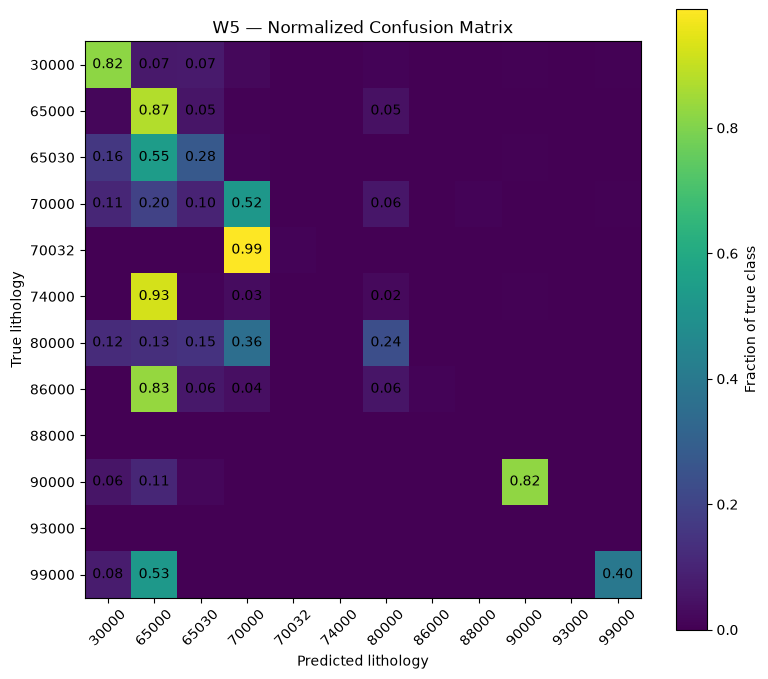

In [80]:
# ============================================================
# W5 — Normalized Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

all_labels_w5 = np.arange(12)

cm_w5 = confusion_matrix(
    y_public_w5_encoded,
    y_pred_w5,
    labels=all_labels_w5
)

# Row-normalize
row_totals = cm_w5.sum(axis=1, keepdims=True)

cm_w5_norm = np.divide(
    cm_w5,
    row_totals,
    out=np.zeros_like(cm_w5, dtype=float),
    where=row_totals != 0
)

print("Confusion matrix shape:", cm_w5.shape)

print("\nNormalized confusion matrix:")
print(np.round(cm_w5_norm, 3))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

plt.imshow(cm_w5_norm, interpolation="nearest")
plt.colorbar(label="Fraction of true class")

plt.xticks(
    all_labels_w5,
    [str(int(x)) for x in label_encoder_w5.classes_],
    rotation=45
)

plt.yticks(
    all_labels_w5,
    [str(int(x)) for x in label_encoder_w5.classes_]
)

plt.xlabel("Predicted lithology")
plt.ylabel("True lithology")
plt.title("W5 — Normalized Confusion Matrix")

for i in range(12):
    for j in range(12):
        if cm_w5_norm[i, j] >= 0.02:
            plt.text(
                j,
                i,
                f"{cm_w5_norm[i, j]:.2f}",
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

| Lithology | Recall | Main confusion |
|---|---:|---|
| Sandstone `30000` | **82.1%** | Shale 6.8%, Sandstone/Shale 7.0% |
| Shale `65000` | **87.3%** | Sandstone/Shale 5.4%, Marl 4.6% |
| Sandstone/Shale `65030` | **27.6%** | **Shale 54.5%**, Sandstone 15.9% |
| Limestone `70000` | **52.3%** | Shale 19.7%, Sandstone 10.5%, Sandstone/Shale 10.0% |
| Chalk `70032` | **1.1%** | **Limestone 98.9%** |
| Dolomite `74000` | **0%** | **Shale 92.5%** |
| Marl `80000` | **23.9%** | Limestone 35.8%, Sandstone/Shale 14.5%, Shale 13.4% |
| Anhydrite `86000` | **0.8%** | **Shale 83.2%** |
| Halite `88000` | — | No PUBLIC samples |
| Coal `90000` | **82.3%** | Shale 10.6%, Sandstone 5.5% |
| Basement `93000` | — | No PUBLIC samples |
| Tuff `99000` | **39.7%** | **Shale 52.6%**, Sandstone 7.7% |

This is not simply a general model weakness.
The model is actually very good at several dominant classes:
- Shale → 87.3%
- Sandstone → 82.1%
- Coal → 82.3%
But it struggles badly with lithologies that are either rare or log-response-overlapping:

Sandstone/Shale → Shale: 54.5%|
Dolomite → Shale: 92.5%|
Anhydrite → Shale: 83.2%|
Chalk → Limestone: 98.9%|
Tuff → Shale: 52.6%||

This is particularly important for your thesis: accuracy alone would hide this behavior. That's exactly why we're looking at macro F1 and per-class recall

In [81]:
# ============================================================
# W5 — Feature Importance
# ============================================================

import pandas as pd
import numpy as np

# W5 model
importances_w5 = et_w5.feature_importances_

feature_importance_w5 = pd.DataFrame({
    "Feature": X_train_eng.columns,
    "Importance": importances_w5
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Top 25 W5 features:")
display(feature_importance_w5.head(25))

Top 25 W5 features:


,Feature,Importance
0,GR_ROLLMEAN_5,0.065336
1,GR_ROLLMEAN_9,0.063548
2,GR_ROLLMEAN_21,0.063111
3,GR,0.053850
4,DTC_ROLLMEAN_21,0.048740
5,DTC_ROLLMEAN_5,0.047294
6,DTC_ROLLMEAN_9,0.047054
7,DTC,0.039519
8,RMED_LOG10_MISSING,0.035202
9,RDEP_LOG10_ROLLMEAN_21,0.032698


In [82]:
# ============================================================
# W5 — Permutation Importance on PUBLIC set
# Metric: Macro F1
# ============================================================

from sklearn.inspection import permutation_importance

print("Calculating permutation importance...")
print("Metric: macro F1")
print("This may take some time.")

perm_w5 = permutation_importance(
    et_w5,
    X_public_eng,
    y_public_w5_encoded,
    scoring="f1_macro",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

permutation_importance_w5 = (
    pd.DataFrame({
        "Feature": X_public_eng.columns,
        "Importance_Mean": perm_w5.importances_mean,
        "Importance_STD": perm_w5.importances_std
    })
    .sort_values("Importance_Mean", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 25 features by permutation importance:")
display(permutation_importance_w5.head(25))

Calculating permutation importance...
Metric: macro F1
This may take some time.

Top 25 features by permutation importance:


,Feature,Importance_Mean,Importance_STD
0,GR_ROLLMEAN_5,0.013146,0.001265
1,DTC_ROLLMEAN_21,0.012518,0.000584
2,RHOB_ROLLMEAN_5,0.010109,0.001514
3,RHOB_ROLLMEAN_21,0.009680,0.000917
4,RHOB_ROLLMEAN_9,0.008938,0.000748
5,RHOB,0.008691,0.000251
6,DTC_ROLLMEAN_5,0.008171,0.001937
7,GR_ROLLMEAN_9,0.007245,0.001824
8,DTC_ROLLMEAN_9,0.005863,0.000974
9,GR,0.005733,0.001748


important freatures 

| Rank | Feature | Macro-F1 decrease |
|---:|---|---:|
| 1 | `GR_ROLLMEAN_5` | **0.01315** |
| 2 | `DTC_ROLLMEAN_21` | **0.01252** |
| 3 | `RHOB_ROLLMEAN_5` | **0.01011** |
| 4 | `RHOB_ROLLMEAN_21` | **0.00968** |
| 5 | `RHOB_ROLLMEAN_9` | **0.00894** |
| 6 | `RHOB` | **0.00869** |
| 7 | `DTC_ROLLMEAN_5` | **0.00817** |
| 8 | `GR_ROLLMEAN_9` | **0.00725** |
| 9 | `DTC_ROLLMEAN_9` | **0.00586** |
| 10 | `GR` | **0.00573** |

In [83]:
# ============================================================
# W5 — Class-specific permutation importance
# Target: Sandstone/Shale (65030)
# ============================================================

from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score, make_scorer

# Encoded class corresponding to 65030
target_code = 65030
target_class = label_encoder_w5.transform([target_code])[0]

print("Lithology code :", target_code)
print("Encoded class  :", target_class)

# Custom scorer: F1 ONLY for Sandstone/Shale
def sandstone_shale_f1(estimator, X, y):
    y_pred = estimator.predict(X)
    return f1_score(
        y,
        y_pred,
        labels=[target_class],
        average="macro",
        zero_division=0
    )

perm_65030 = permutation_importance(
    et_w5,
    X_public_eng,
    y_public_w5_encoded,
    scoring=sandstone_shale_f1,
    n_repeats=2,
    random_state=42,
    n_jobs=-1
)

perm_65030_df = (
    pd.DataFrame({
        "Feature": X_public_eng.columns,
        "Importance_Mean": perm_65030.importances_mean,
        "Importance_STD": perm_65030.importances_std
    })
    .sort_values("Importance_Mean", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 features for Sandstone/Shale F1:")
display(perm_65030_df.head(20))

Lithology code : 65030
Encoded class  : 2

Top 20 features for Sandstone/Shale F1:


,Feature,Importance_Mean,Importance_STD
0,RHOB_ROLLMEAN_5,0.028316,0.000509
1,RHOB_ROLLMEAN_9,0.026721,0.000437
2,DTC_ROLLMEAN_5,0.026098,0.000211
3,DTC_ROLLMEAN_9,0.025039,0.000991
4,RHOB_ROLLMEAN_21,0.023822,0.000074
5,RHOB,0.022671,0.000372
6,RDEP_LOG10_ROLLMEAN_9,0.021795,0.000654
7,GR,0.020670,0.001328
8,DTC_ROLLMEAN_21,0.020176,0.000333
9,GR_ROLLMEAN_5,0.019977,0.000064


In [84]:
# ============================================================
# W5 — Probability analysis for Sandstone/Shale (65030)
# ============================================================

import pandas as pd
import numpy as np

# Get probabilities
proba_w5 = et_w5.predict_proba(X_public_eng)

target_code = 65030
target_class = label_encoder_w5.transform([target_code])[0]

# True 65030 samples
mask_65030 = y_public_w5_encoded == target_class

true_65030_idx = np.where(mask_65030)[0]

# Probability assigned to the TRUE class
p_true = proba_w5[true_65030_idx, target_class]

# Predicted class
pred_65030 = y_pred_w5[true_65030_idx]

# Maximum probability
p_max = proba_w5[true_65030_idx].max(axis=1)

correct = pred_65030 == target_class
wrong = ~correct

print("True 65030 samples:", len(true_65030_idx))

print("\nCorrectly predicted 65030:")
print("Count              :", correct.sum())
print("Mean P(65030)      :", p_true[correct].mean())
print("Median P(65030)    :", np.median(p_true[correct]))

print("\nMisclassified 65030:")
print("Count              :", wrong.sum())
print("Mean P(65030)      :", p_true[wrong].mean())
print("Median P(65030)    :", np.median(p_true[wrong]))

print("\nMaximum probability:")
print("Correct predictions :", p_max[correct].mean())
print("Wrong predictions   :", p_max[wrong].mean())

# ------------------------------------------------------------
# Most common predicted classes for true 65030
# ------------------------------------------------------------

pred_codes = label_encoder_w5.inverse_transform(pred_65030)

print("\nPredictions for true 65030:")
print(
    pd.Series(pred_codes)
    .value_counts()
    .head(10)
)

# ------------------------------------------------------------
# Probability distribution summary
# ------------------------------------------------------------

print("\nP(65030) quantiles:")
print(
    pd.Series(p_true).quantile(
        [0, .1, .25, .5, .75, .9, 1.0]
    )
)

True 65030 samples: 17558

Correctly predicted 65030:
Count              : 4840
Mean P(65030)      : 0.44188626402683573
Median P(65030)    : 0.4165444006909941

Misclassified 65030:
Count              : 12718
Mean P(65030)      : 0.17258718158344702
Median P(65030)    : 0.1503915590887422

Maximum probability:
Correct predictions : 0.44188626402683573
Wrong predictions   : 0.5255190373343638

Predictions for true 65030:
65000.0    9575
65030.0    4840
30000.0    2783
70000.0     142
90000.0     117
99000.0      59
80000.0      38
70032.0       4
Name: count, dtype: int64

P(65030) quantiles:
0.00    0.013651
0.10    0.065152
0.25    0.100912
0.50    0.225820
0.75    0.354302
0.90    0.453078
1.00    0.741443
dtype: float64


| True 65030 | Mean P(65030) |
|---|---:|
| Correctly classified | **0.442** |
| Misclassified | **0.173** |


The really interesting part
The model's P(65030) distribution is:
- 10th percentile: 0.065
- 25th: 0.101
- Median: 0.226
- 75th: 0.354
- 90th: 0.453
- Maximum: 0.741
So there is a substantial population of 65030 samples for which the model sees very little evidence for 65030.
That suggests this isn't simply:
"The model knows it's 65030 but chooses Shale because of the class imbalance."

There is likely substantial feature-space overlap between 65030 and 65000.
And this agrees with our confusion matrix and feature analysis.

For the true 65030 samples that were predicted as Shale,
P(Shale) vs P(Sandstone/Shale) vs P(Sandstone).

In [85]:
# ============================================================
# W5 — 65030 decision competition
# ============================================================

# Encoded classes
cls_65000 = label_encoder_w5.transform([65000])[0]
cls_65030 = label_encoder_w5.transform([65030])[0]
cls_30000 = label_encoder_w5.transform([30000])[0]

# True 65030 samples
mask_65030 = y_public_w5_encoded == cls_65030

# Among true 65030, find those predicted as Shale
mask_65030_to_shale = (
    mask_65030 &
    (y_pred_w5 == cls_65000)
)

p = proba_w5[mask_65030_to_shale]

print("True 65030 → predicted 65000")
print("Samples:", len(p))

print("\nMean probabilities:")
print(f"P(65000 Shale)          : {p[:, cls_65000].mean():.4f}")
print(f"P(65030 Sandstone/Shale): {p[:, cls_65030].mean():.4f}")
print(f"P(30000 Sandstone)      : {p[:, cls_30000].mean():.4f}")

print("\nMedian probabilities:")
print(f"P(65000 Shale)          : {np.median(p[:, cls_65000]):.4f}")
print(f"P(65030 Sandstone/Shale): {np.median(p[:, cls_65030]):.4f}")
print(f"P(30000 Sandstone)      : {np.median(p[:, cls_30000]):.4f}")

True 65030 → predicted 65000
Samples: 9575

Mean probabilities:
P(65000 Shale)          : 0.5544
P(65030 Sandstone/Shale): 0.1651
P(30000 Sandstone)      : 0.1151

Median probabilities:
P(65000 Shale)          : 0.5474
P(65030 Sandstone/Shale): 0.1272
P(30000 Sandstone)      : 0.0977


In [86]:
# ============================================================
# PUBLIC feature distributions:
# Shale vs Sandstone/Shale vs Sandstone
# ============================================================

import pandas as pd
import numpy as np

codes = [65000, 65030, 30000]

feature_cols = [
    "GR",
    "RDEP_LOG10",
    "RMED_LOG10",
    "DTC",
    "RHOB"
]

# Build a dataframe from PUBLIC
public_analysis = X_public_eng[feature_cols].copy()
public_analysis["LITHOLOGY"] = y_public_w5.values

# ------------------------------------------------------------
# Median and IQR
# ------------------------------------------------------------

summary = []

for code in codes:
    subset = public_analysis[
        public_analysis["LITHOLOGY"] == code
    ]

    for feature in feature_cols:
        values = subset[feature].dropna()

        summary.append({
            "Lithology": code,
            "Feature": feature,
            "N": len(values),
            "Median": values.median(),
            "Q25": values.quantile(0.25),
            "Q75": values.quantile(0.75),
            "IQR": values.quantile(0.75) - values.quantile(0.25)
        })

feature_overlap = pd.DataFrame(summary)

display(feature_overlap)

,Lithology,Feature,N,Median,Q25,Q75,IQR
0,65000,GR,84030,68.602638,53.453873,91.685938,38.232065
1,65000,RDEP_LOG10,84030,0.217629,0.029957,0.367817,0.337860
2,65000,RMED_LOG10,84030,0.218892,0.044714,0.350427,0.305713
3,65000,DTC,84030,105.854694,92.485916,134.684181,42.198265
4,65000,RHOB,84030,2.333570,2.172039,2.511880,0.339841
5,65030,GR,17558,62.377920,49.073889,73.835888,24.761999
6,65030,RDEP_LOG10,17558,0.128796,-0.063615,0.711294,0.774909
7,65030,RMED_LOG10,17558,0.136020,-0.054025,0.740516,0.794541
8,65030,DTC,17558,109.560997,81.600088,142.484478,60.884390
9,65030,RHOB,17558,2.321426,2.017880,2.537295,0.519414


| Feature | Shale 65000 median | Sandstone/Shale 65030 median | Sandstone 30000 median |
|---|---:|---:|---:|
| GR | 68.60 | 62.38 | 35.14 |
| RDEP_LOG10 | 0.218 | 0.129 | −0.009 |
| RMED_LOG10 | 0.219 | 0.136 | 0.005 |
| DTC | 105.85 | 109.56 | 97.36 |
| RHOB | **2.334** | **2.321** | **2.321** |

In [87]:
# ============================================================
# Lithology run-length analysis
# 65000 vs 65030 vs 30000
# ============================================================

import pandas as pd
import numpy as np

codes = [65000, 65030, 30000]

# Use the engineered dataframe with original row order
run_df = df[["WELL", TARGET]].copy()

# Identify changes within each well
run_df["NEW_RUN"] = (
    run_df[TARGET] != run_df.groupby("WELL")[TARGET].shift()
)

run_df["RUN_ID"] = (
    run_df.groupby("WELL")["NEW_RUN"]
    .cumsum()
)

# Count samples in each lithology run
runs = (
    run_df
    .groupby(["WELL", "RUN_ID", TARGET])
    .size()
    .reset_index(name="N_SAMPLES")
)

# Convert samples to metres
runs["THICKNESS_M"] = runs["N_SAMPLES"] * 0.152

for code in codes:

    subset = runs[runs[TARGET] == code]

    print(f"\n========== {code} ==========")
    print("Number of runs :", len(subset))
    print("Total samples  :", subset["N_SAMPLES"].sum())

    print("\nRun-length statistics (samples):")
    print(
        subset["N_SAMPLES"]
        .describe(percentiles=[.1, .25, .5, .75, .9, .95])
    )

    print("\nThickness statistics (m):")
    print(
        subset["THICKNESS_M"]
        .describe(percentiles=[.1, .25, .5, .75, .9, .95])
    )


========== 65000 ==========
Number of runs : 14024
Total samples  : 877042

Run-length statistics (samples):
count    14024.000000
mean        62.538648
std        164.647201
min          1.000000
10%          4.000000
25%          7.000000
50%         17.000000
75%         50.000000
90%        146.000000
95%        264.000000
max       4353.000000
Name: N_SAMPLES, dtype: float64

Thickness statistics (m):
count    14024.000000
mean         9.505875
std         25.026374
min          0.152000
10%          0.608000
25%          1.064000
50%          2.584000
75%          7.600000
90%         22.192000
95%         40.128000
max        661.656000
Name: THICKNESS_M, dtype: float64

========== 65030 ==========
Number of runs : 9829
Total samples  : 180446

Run-length statistics (samples):
count    9829.000000
mean       18.358531
std        54.345812
min         1.000000
10%         3.000000
25%         4.000000
50%         8.000000
75%        16.000000
90%        36.000000
95%        61.0

| Lithology | Median thickness | 75th percentile | 90th percentile |
|---|---:|---:|---:|
| Shale `65000` | **2.584 m** | **7.60 m** | **22.19 m** |
| Sandstone/Shale `65030` | **1.216 m** | **2.43 m** | **5.47 m** |
| Sandstone `30000` | **1.520 m** | **4.10 m** | **9.27 m** |

creating internal validation well

In [88]:
# ============================================================
# INTERNAL TRAIN / VALIDATION SPLIT
# Well-level split inside the official TRAIN wells
# ============================================================

from sklearn.model_selection import train_test_split

# Official TRAIN wells only
train_wells = np.sort(
    df.loc[df["SPLIT"] == "TRAIN", "WELL"].unique()
)

print("Official TRAIN wells:", len(train_wells))

# 80/20 well-level split
internal_train_wells, internal_val_wells = train_test_split(
    train_wells,
    test_size=0.20,
    random_state=42
)

print("Internal TRAIN wells     :", len(internal_train_wells))
print("Internal VALIDATION wells:", len(internal_val_wells))

print("\nOverlap check:")
print(
    "Overlapping wells:",
    len(
        set(internal_train_wells)
        &
        set(internal_val_wells)
    )
)

# ------------------------------------------------------------
# Create row masks
# ------------------------------------------------------------

internal_train_mask = (
    df["WELL"].isin(internal_train_wells)
    &
    (df["SPLIT"] == "TRAIN")
)

internal_val_mask = (
    df["WELL"].isin(internal_val_wells)
    &
    (df["SPLIT"] == "TRAIN")
)

print("\nSamples:")
print(
    "Internal TRAIN     :",
    internal_train_mask.sum()
)

print(
    "Internal VALIDATION:",
    internal_val_mask.sum()
)

print(
    "Total official TRAIN:",
    (df["SPLIT"] == "TRAIN").sum()
)

print(
    "Sum:",
    internal_train_mask.sum() + internal_val_mask.sum()
)

Official TRAIN wells: 98
Internal TRAIN wells     : 78
Internal VALIDATION wells: 20

Overlap check:
Overlapping wells: 0

Samples:
Internal TRAIN     : 894965
Internal VALIDATION: 276592
Total official TRAIN: 1171557
Sum: 1171557


In [5]:
# ============================================================
# Leakage-free INTERNAL TRAIN / VALIDATION datasets
# ============================================================

# Continuous engineered features
INTERNAL_CONTINUOUS_FEATURES = (
    BASELINE_FEATURES
    + ROLLING_FEATURES
    + ["RESISTIVITY_SEPARATION"]
)

INTERNAL_MISSING_FEATURES = [
    f"{feature}_MISSING"
    for feature in BASELINE_FEATURES
]

# ------------------------------------------------------------
# 1. Extract features directly from engineered dataframe
# ------------------------------------------------------------

X_internal_train = df.loc[
    internal_train_mask,
    ENGINEERED_FEATURES
].copy()

X_internal_val = df.loc[
    internal_val_mask,
    ENGINEERED_FEATURES
].copy()

y_internal_train = df.loc[
    internal_train_mask,
    TARGET
].copy()

y_internal_val = df.loc[
    internal_val_mask,
    TARGET
].copy()

print("X internal TRAIN :", X_internal_train.shape)
print("X internal VAL   :", X_internal_val.shape)
print("y internal TRAIN :", y_internal_train.shape)
print("y internal VAL   :", y_internal_val.shape)

# ------------------------------------------------------------
# 2. Calculate medians ONLY from internal TRAIN
# ------------------------------------------------------------

internal_train_medians = (
    X_internal_train[INTERNAL_CONTINUOUS_FEATURES]
    .median()
)

# ------------------------------------------------------------
# 3. Apply same internal-TRAIN medians to both sets
# ------------------------------------------------------------

X_internal_train[INTERNAL_CONTINUOUS_FEATURES] = (
    X_internal_train[INTERNAL_CONTINUOUS_FEATURES]
    .fillna(internal_train_medians)
)

X_internal_val[INTERNAL_CONTINUOUS_FEATURES] = (
    X_internal_val[INTERNAL_CONTINUOUS_FEATURES]
    .fillna(internal_train_medians)
)

# ------------------------------------------------------------
# 4. Validation checks
# ------------------------------------------------------------

print("\nNaN counts:")
print("Internal TRAIN:", X_internal_train.isna().sum().sum())
print("Internal VAL  :", X_internal_val.isna().sum().sum())

print("\nInf counts:")
print(
    "Internal TRAIN:",
    np.isinf(X_internal_train.to_numpy()).sum()
)

print(
    "Internal VAL  :",
    np.isinf(X_internal_val.to_numpy()).sum()
)

print("\nFeatures:", X_internal_train.shape[1])

NameError: name 'BASELINE_FEATURES' is not defined

In [90]:
# ============================================================
# INTERNAL BASELINE — W5 Extra Trees
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from time import perf_counter
import numpy as np

# ------------------------------------------------------------
# 1. Encode labels using INTERNAL TRAIN only
# ------------------------------------------------------------

label_encoder_internal = LabelEncoder()

y_internal_train_encoded = (
    label_encoder_internal.fit_transform(y_internal_train)
)

y_internal_val_encoded = (
    label_encoder_internal.transform(y_internal_val)
)

# ------------------------------------------------------------
# 2. Square-root balanced class weights
# ------------------------------------------------------------

classes_internal = np.unique(y_internal_train_encoded)

balanced_weights_internal = compute_class_weight(
    class_weight="balanced",
    classes=classes_internal,
    y=y_internal_train_encoded
)

sqrt_weights_internal = {
    int(cls): float(np.sqrt(weight))
    for cls, weight in zip(
        classes_internal,
        balanced_weights_internal
    )
}

print("Internal class weights:")
for cls, weight in sqrt_weights_internal.items():
    code = label_encoder_internal.inverse_transform([cls])[0]
    print(f"{int(code):5d} -> {weight:.4f}")

# ------------------------------------------------------------
# 3. Train
# ------------------------------------------------------------

et_internal = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight=sqrt_weights_internal,
    n_jobs=-1,
    random_state=42
)

t0 = perf_counter()

et_internal.fit(
    X_internal_train,
    y_internal_train_encoded
)

train_time_internal = perf_counter() - t0

# ------------------------------------------------------------
# 4. Predict
# ------------------------------------------------------------

t0 = perf_counter()

y_pred_internal = et_internal.predict(
    X_internal_val
)

prediction_time_internal = perf_counter() - t0

# ------------------------------------------------------------
# 5. Metrics
# ------------------------------------------------------------

accuracy_internal = accuracy_score(
    y_internal_val_encoded,
    y_pred_internal
)

balanced_acc_internal = balanced_accuracy_score(
    y_internal_val_encoded,
    y_pred_internal
)

macro_f1_internal = f1_score(
    y_internal_val_encoded,
    y_pred_internal,
    average="macro"
)

weighted_f1_internal = f1_score(
    y_internal_val_encoded,
    y_pred_internal,
    average="weighted"
)

print("\n================ INTERNAL W5 BASELINE ================")
print(f"Accuracy          : {accuracy_internal:.4f}")
print(f"Balanced Accuracy : {balanced_acc_internal:.4f}")
print(f"Macro F1          : {macro_f1_internal:.4f}")
print(f"Weighted F1       : {weighted_f1_internal:.4f}")
print(f"Training time     : {train_time_internal:.2f} s")
print(f"Prediction time   : {prediction_time_internal:.2f} s")

Internal class weights:
30000 -> 0.7534
65000 -> 0.3700
65030 -> 0.7842
70000 -> 1.3036
70032 -> 3.0652
74000 -> 7.9066
80000 -> 1.8251
86000 -> 9.3947
88000 -> 4.1574
90000 -> 4.7496
93000 -> 22.9987
99000 -> 2.3586

================ INTERNAL W5 BASELINE ================
Accuracy          : 0.7310
Balanced Accuracy : 0.3752
Macro F1          : 0.3687
Weighted F1       : 0.7074
Training time     : 30.35 s
Prediction time   : 1.22 s


| Metric | PUBLIC W5 | Internal W5 |
|---|---:|---:|
| Accuracy | 0.7476 | 0.7310 |
| Balanced Accuracy | 0.3971 | **0.3752** |
| Macro F1 | 0.3447 | **0.3687** |
| Weighted F1 | 0.7390 | 0.7074 |

In [91]:
# ============================================================
# W9 — Extra Trees with alpha=0.75 class weighting
# Internal validation only
# ============================================================

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)
from time import perf_counter
import numpy as np

# ------------------------------------------------------------
# Alpha = 0.75
# ------------------------------------------------------------

alpha_w9 = 0.75

w9_class_weights = {
    int(cls): float(weight ** alpha_w9)
    for cls, weight in zip(
        classes_internal,
        balanced_weights_internal
    )
}

print("W9 class weights:")

for cls, weight in w9_class_weights.items():
    code = label_encoder_internal.inverse_transform([cls])[0]
    print(f"{int(code):5d} -> {weight:.4f}")

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

et_w9 = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight=w9_class_weights,
    n_jobs=-1,
    random_state=42
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

t0 = perf_counter()

et_w9.fit(
    X_internal_train,
    y_internal_train_encoded
)

train_time_w9 = perf_counter() - t0

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

t0 = perf_counter()

y_pred_w9 = et_w9.predict(
    X_internal_val
)

prediction_time_w9 = perf_counter() - t0

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

acc_w9 = accuracy_score(
    y_internal_val_encoded,
    y_pred_w9
)

bal_acc_w9 = balanced_accuracy_score(
    y_internal_val_encoded,
    y_pred_w9
)

macro_f1_w9 = f1_score(
    y_internal_val_encoded,
    y_pred_w9,
    average="macro"
)

weighted_f1_w9 = f1_score(
    y_internal_val_encoded,
    y_pred_w9,
    average="weighted"
)

print("\n================ W9 α=0.75 ================")
print(f"Accuracy          : {acc_w9:.4f}")
print(f"Balanced Accuracy : {bal_acc_w9:.4f}")
print(f"Macro F1          : {macro_f1_w9:.4f}")
print(f"Weighted F1       : {weighted_f1_w9:.4f}")
print(f"Training time     : {train_time_w9:.2f} s")
print(f"Prediction time   : {prediction_time_w9:.2f} s")

W9 class weights:
30000 -> 0.6539
65000 -> 0.2250
65030 -> 0.6945
70000 -> 1.4883
70032 -> 5.3664
74000 -> 22.2325
80000 -> 2.4657
86000 -> 28.7956
88000 -> 8.4768
90000 -> 10.3512
93000 -> 110.2946
99000 -> 3.6222

================ W9 α=0.75 ================
Accuracy          : 0.7016
Balanced Accuracy : 0.4565
Macro F1          : 0.3374
Weighted F1       : 0.7053
Training time     : 29.58 s
Prediction time   : 1.17 s


| Metric | W5 α=0.50 | W9 α=0.75 | Change |
|---|---:|---:|---:|
| Accuracy | **0.7310** | 0.7016 | −0.0294 |
| Balanced Accuracy | 0.3752 | **0.4565** | **+0.0813** |
| Macro F1 | **0.3687** | 0.3374 | −0.0313 |
| Weighted F1 | 0.7074 | 0.7053 | −0.0021 |

In [13]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles one level above:")
print(os.listdir(".."))

print("\nEngineered file exists:")
print(os.path.exists("../data/processed/engineered_features.parquet"))

print("\nSplit file exists:")
print(os.path.exists("../data/splits/force2020_split.csv"))

Current working directory:
/Users/akashray/Lithology_Predictor/notebooks

Files one level above:
['.DS_Store', 'app', 'LICENSE', 'requirements.txt', 'pyproject.toml', 'features', 'tests', 'models', 'docs', 'README.md', 'results', '.gitignore', '.venv', 'evaluation', 'preprocessing', '.git', 'data', 'notebooks', 'src']

Engineered file exists:
True

Split file exists:
True


In [14]:
# ============================================================
# RECOVER NOTEBOOK STATE — CORE DATA
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ENGINEERED_PATH = "../data/processed/engineered_features.parquet"
SPLIT_PATH = "../data/splits/force2020_split.csv"

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

df = pd.read_parquet(ENGINEERED_PATH)
split_manifest = pd.read_csv(SPLIT_PATH)

print("Engineered data:", df.shape)
print("Split manifest :", split_manifest.shape)

# ------------------------------------------------------------
# Restore official split
# ------------------------------------------------------------

df = df.drop(columns=["SPLIT"], errors="ignore")

df = df.merge(
    split_manifest[["WELL", "SPLIT"]],
    on="WELL",
    how="left",
    validate="many_to_one"
)

print("\nOfficial split:")
print(df["SPLIT"].value_counts())

print("\nWells per split:")
print(df.groupby("SPLIT")["WELL"].nunique())

# ------------------------------------------------------------
# Feature definitions
# ------------------------------------------------------------

BASELINE_FEATURES = [
    "GR",
    "RDEP_LOG10",
    "RMED_LOG10",
    "DTC",
    "RHOB"
]

ROLLING_FEATURES = [
    c for c in df.columns
    if "_ROLLMEAN_" in c or "_ROLLSTD_" in c
]

MISSING_FEATURES = [
    f"{feature}_MISSING"
    for feature in BASELINE_FEATURES
]

ENGINEERED_FEATURES = (
    BASELINE_FEATURES
    + ROLLING_FEATURES
    + ["RESISTIVITY_SEPARATION"]
    + MISSING_FEATURES
)

TARGET = "FORCE_2020_LITHOFACIES_LITHOLOGY"

print("\nFeature counts:")
print("Baseline :", len(BASELINE_FEATURES))
print("Rolling  :", len(ROLLING_FEATURES))
print("Missing  :", len(MISSING_FEATURES))
print("Total    :", len(ENGINEERED_FEATURES))

print("\nNaNs in engineered features:",
      df[ENGINEERED_FEATURES].isna().sum().sum())

Engineered data: (1430974, 46)
Split manifest : (118, 2)

Official split:
SPLIT
TRAIN         1171557
PUBLIC         136841
BLIND_TEST     122576
Name: count, dtype: int64

Wells per split:
SPLIT
BLIND_TEST    10
PUBLIC        10
TRAIN         98
Name: WELL, dtype: int64

Feature counts:
Baseline : 5
Rolling  : 30
Missing  : 5
Total    : 41

NaNs in engineered features: 2390805


In [15]:
# ============================================================
# RECOVER INTERNAL 78/20 WELL SPLIT
# + LEAKAGE-FREE IMPUTATION
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Official TRAIN wells only
# ------------------------------------------------------------

train_wells = np.sort(
    df.loc[df["SPLIT"] == "TRAIN", "WELL"].unique()
)

internal_train_wells, internal_val_wells = train_test_split(
    train_wells,
    test_size=0.20,
    random_state=42
)

print("Official TRAIN wells       :", len(train_wells))
print("Internal TRAIN wells       :", len(internal_train_wells))
print("Internal VALIDATION wells :", len(internal_val_wells))

print(
    "Well overlap:",
    len(set(internal_train_wells) & set(internal_val_wells))
)

# ------------------------------------------------------------
# 2. Row masks
# ------------------------------------------------------------

internal_train_mask = (
    df["SPLIT"].eq("TRAIN")
    & df["WELL"].isin(internal_train_wells)
)

internal_val_mask = (
    df["SPLIT"].eq("TRAIN")
    & df["WELL"].isin(internal_val_wells)
)

print("\nSamples:")
print("Internal TRAIN     :", internal_train_mask.sum())
print("Internal VALIDATION:", internal_val_mask.sum())

# ------------------------------------------------------------
# 3. Extract 41 engineered features
# ------------------------------------------------------------

X_internal_train = df.loc[
    internal_train_mask,
    ENGINEERED_FEATURES
].copy()

X_internal_val = df.loc[
    internal_val_mask,
    ENGINEERED_FEATURES
].copy()

y_internal_train = df.loc[
    internal_train_mask,
    TARGET
].copy()

y_internal_val = df.loc[
    internal_val_mask,
    TARGET
].copy()

# ------------------------------------------------------------
# 4. Continuous features
# ------------------------------------------------------------

INTERNAL_CONTINUOUS_FEATURES = (
    BASELINE_FEATURES
    + ROLLING_FEATURES
    + ["RESISTIVITY_SEPARATION"]
)

# ------------------------------------------------------------
# 5. Training-only medians
# ------------------------------------------------------------

internal_train_medians = (
    X_internal_train[
        INTERNAL_CONTINUOUS_FEATURES
    ].median()
)

# ------------------------------------------------------------
# 6. Apply ONLY internal-training medians
# ------------------------------------------------------------

X_internal_train[
    INTERNAL_CONTINUOUS_FEATURES
] = X_internal_train[
    INTERNAL_CONTINUOUS_FEATURES
].fillna(internal_train_medians)

X_internal_val[
    INTERNAL_CONTINUOUS_FEATURES
] = X_internal_val[
    INTERNAL_CONTINUOUS_FEATURES
].fillna(internal_train_medians)

# ------------------------------------------------------------
# 7. Final checks
# ------------------------------------------------------------

print("\nShapes:")
print("X internal TRAIN :", X_internal_train.shape)
print("X internal VAL   :", X_internal_val.shape)
print("y internal TRAIN :", y_internal_train.shape)
print("y internal VAL   :", y_internal_val.shape)

print("\nNaNs:")
print("TRAIN:", X_internal_train.isna().sum().sum())
print("VAL  :", X_internal_val.isna().sum().sum())

print("\nInfs:")
print(
    "TRAIN:",
    np.isinf(X_internal_train.to_numpy()).sum()
)
print(
    "VAL  :",
    np.isinf(X_internal_val.to_numpy()).sum()
)

Official TRAIN wells       : 98
Internal TRAIN wells       : 78
Internal VALIDATION wells : 20
Well overlap: 0

Samples:
Internal TRAIN     : 894965
Internal VALIDATION: 276592

Shapes:
X internal TRAIN : (894965, 41)
X internal VAL   : (276592, 41)
y internal TRAIN : (894965,)
y internal VAL   : (276592,)

NaNs:
TRAIN: 0
VAL  : 0

Infs:
TRAIN: 0
VAL  : 0


In [16]:
# ============================================================
# INTERNAL W5 BASELINE — REBUILD
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)
from time import perf_counter

# ------------------------------------------------------------
# 1. Encode labels using internal TRAIN only
# ------------------------------------------------------------

label_encoder_internal = LabelEncoder()

y_internal_train_encoded = (
    label_encoder_internal.fit_transform(
        y_internal_train
    )
)

y_internal_val_encoded = (
    label_encoder_internal.transform(
        y_internal_val
    )
)

# ------------------------------------------------------------
# 2. Balanced weights
# ------------------------------------------------------------

classes_internal = np.unique(
    y_internal_train_encoded
)

balanced_weights_internal = compute_class_weight(
    class_weight="balanced",
    classes=classes_internal,
    y=y_internal_train_encoded
)

# W5 = square-root balanced weighting
sqrt_weights_internal = {
    int(cls): float(np.sqrt(weight))
    for cls, weight in zip(
        classes_internal,
        balanced_weights_internal
    )
}

# ------------------------------------------------------------
# 3. Train W5
# ------------------------------------------------------------

et_internal = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    class_weight=sqrt_weights_internal,
    n_jobs=-1,
    random_state=42
)

t0 = perf_counter()

et_internal.fit(
    X_internal_train,
    y_internal_train_encoded
)

train_time_internal = perf_counter() - t0

# ------------------------------------------------------------
# 4. Predict
# ------------------------------------------------------------

t0 = perf_counter()

y_pred_internal = et_internal.predict(
    X_internal_val
)

prediction_time_internal = perf_counter() - t0

# ------------------------------------------------------------
# 5. Metrics
# ------------------------------------------------------------

accuracy_internal = accuracy_score(
    y_internal_val_encoded,
    y_pred_internal
)

balanced_acc_internal = balanced_accuracy_score(
    y_internal_val_encoded,
    y_pred_internal
)

macro_f1_internal = f1_score(
    y_internal_val_encoded,
    y_pred_internal,
    average="macro"
)

weighted_f1_internal = f1_score(
    y_internal_val_encoded,
    y_pred_internal,
    average="weighted"
)

print("\n================ INTERNAL W5 ================")
print(f"Accuracy          : {accuracy_internal:.4f}")
print(f"Balanced Accuracy : {balanced_acc_internal:.4f}")
print(f"Macro F1          : {macro_f1_internal:.4f}")
print(f"Weighted F1       : {weighted_f1_internal:.4f}")
print(f"Training time     : {train_time_internal:.2f} s")
print(f"Prediction time   : {prediction_time_internal:.2f} s")


================ INTERNAL W5 ================
Accuracy          : 0.7310
Balanced Accuracy : 0.3752
Macro F1          : 0.3687
Weighted F1       : 0.7074
Training time     : 29.28 s
Prediction time   : 1.21 s


Internal XGBoost baseline

In [17]:
# ============================================================
# RESTORE NOTEBOOK STATE — DATA + FEATURE DEFINITIONS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

from time import perf_counter


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ENGINEERED_PATH = "../data/processed/engineered_features.parquet"
SPLIT_PATH = "../data/splits/force2020_split.csv"

print("Engineered file:", ENGINEERED_PATH)
print("Split file     :", SPLIT_PATH)

print("Engineered data:", df.shape)
print("Split manifest :", split_manifest.shape)


# ------------------------------------------------------------
# Attach official FORCE 2020 split
# ------------------------------------------------------------

df = df.drop(columns=["SPLIT"], errors="ignore")

df = df.merge(
    split_manifest[["WELL", "SPLIT"]],
    on="WELL",
    how="left",
    validate="many_to_one"
)

print("\nSplit counts:")
print(df["SPLIT"].value_counts())

print("\nSplit wells:")
print(df.groupby("SPLIT")["WELL"].nunique())


# ------------------------------------------------------------
# Feature definitions
# ------------------------------------------------------------

BASELINE_FEATURES = [
    "GR",
    "RDEP_LOG10",
    "RMED_LOG10",
    "DTC",
    "RHOB"
]

ROLLING_FEATURES = [
    c for c in df.columns
    if "_ROLLMEAN_" in c or "_ROLLSTD_" in c
]

MISSING_FEATURES = [
    f"{feature}_MISSING"
    for feature in BASELINE_FEATURES
]

ENGINEERED_FEATURES = (
    BASELINE_FEATURES
    + ROLLING_FEATURES
    + ["RESISTIVITY_SEPARATION"]
    + MISSING_FEATURES
)

TARGET = "FORCE_2020_LITHOFACIES_LITHOLOGY"


print("\nFeature counts:")
print("Baseline :", len(BASELINE_FEATURES))
print("Rolling  :", len(ROLLING_FEATURES))
print("Missing  :", len(MISSING_FEATURES))
print("Total    :", len(ENGINEERED_FEATURES))

print("\nTarget:", TARGET)

print("\nNaNs in engineered features:",
      df[ENGINEERED_FEATURES].isna().sum().sum())

Engineered file: ../data/processed/engineered_features.parquet
Split file     : ../data/splits/force2020_split.csv
Engineered data: (1430974, 46)
Split manifest : (118, 2)

Split counts:
SPLIT
TRAIN         1171557
PUBLIC         136841
BLIND_TEST     122576
Name: count, dtype: int64

Split wells:
SPLIT
BLIND_TEST    10
PUBLIC        10
TRAIN         98
Name: WELL, dtype: int64

Feature counts:
Baseline : 5
Rolling  : 30
Missing  : 5
Total    : 41

Target: FORCE_2020_LITHOFACIES_LITHOLOGY

NaNs in engineered features: 2390805


In [18]:
# ============================================================
# INTERNAL XGBoost BASELINE
# 41 engineered features
# No class weighting
# ============================================================

from xgboost import XGBClassifier
from time import perf_counter

xgb_internal = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=12,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

t0 = perf_counter()

xgb_internal.fit(
    X_internal_train,
    y_internal_train_encoded
)

train_time_xgb_internal = perf_counter() - t0

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

t0 = perf_counter()

y_pred_xgb_internal = xgb_internal.predict(
    X_internal_val
)

prediction_time_xgb_internal = perf_counter() - t0

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

acc_xgb_internal = accuracy_score(
    y_internal_val_encoded,
    y_pred_xgb_internal
)

bal_acc_xgb_internal = balanced_accuracy_score(
    y_internal_val_encoded,
    y_pred_xgb_internal
)

macro_f1_xgb_internal = f1_score(
    y_internal_val_encoded,
    y_pred_xgb_internal,
    average="macro"
)

weighted_f1_xgb_internal = f1_score(
    y_internal_val_encoded,
    y_pred_xgb_internal,
    average="weighted"
)

print("\n================ INTERNAL XGBoost ================")
print(f"Accuracy          : {acc_xgb_internal:.4f}")
print(f"Balanced Accuracy : {bal_acc_xgb_internal:.4f}")
print(f"Macro F1          : {macro_f1_xgb_internal:.4f}")
print(f"Weighted F1       : {weighted_f1_xgb_internal:.4f}")
print(f"Training time     : {train_time_xgb_internal:.2f} s")
print(f"Prediction time   : {prediction_time_xgb_internal:.2f} s")



================ INTERNAL XGBoost ================
Accuracy          : 0.7492
Balanced Accuracy : 0.3247
Macro F1          : 0.3578
Weighted F1       : 0.7093
Training time     : 71.47 s
Prediction time   : 1.68 s


| Model | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| **W5 Extra Trees √weight** | 0.7310 | **0.3752** | **0.3687** | 0.7074 |
| XGBoost | **0.7492** | 0.3247 | 0.3578 | **0.7093** |

In [19]:
# ============================================================
# INTERNAL XGBoost — Per-class evaluation
# ============================================================

all_labels_internal = np.arange(12)

print(
    classification_report(
        y_internal_val_encoded,
        y_pred_xgb_internal,
        labels=all_labels_internal,
        target_names=[
            str(int(x))
            for x in label_encoder_internal.classes_
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       30000       0.67      0.70      0.68     38013
       65000       0.81      0.95      0.87    176301
       65030       0.34      0.16      0.22     29339
       70000       0.51      0.59      0.55     12431
       70032       0.12      0.02      0.03      2575
       74000       0.16      0.02      0.03       495
       80000       0.71      0.07      0.12     10947
       86000       0.70      0.30      0.42       240
       88000       1.00      0.16      0.28      3899
       90000       0.71      0.53      0.61       514
       93000       0.00      0.00      0.00         0
       99000       0.23      0.08      0.12      1838

    accuracy                           0.75    276592
   macro avg       0.50      0.30      0.33    276592
weighted avg       0.71      0.75      0.71    276592



| Class | XGBoost recall | What it means |
|---|---:|---|
| 65000 Shale | **0.95** | Very strong |
| 30000 Sandstone | 0.70 | Good |
| 65030 Sandstone/Shale | **0.16** | Very poor |
| 70000 Limestone | 0.59 | Good |
| 70032 Chalk | 0.02 | Essentially missed |
| 74000 Dolomite | 0.02 | Essentially missed |
| 80000 Marl | **0.07** | Very poor |
| 86000 Anhydrite | 0.30 | Better |
| 88000 Halite | 0.16 | Some detection |
| 90000 Coal | 0.53 | Moderate |
| 99000 Tuff | 0.08 | Very poor |

In [20]:
# ============================================================
# INTERNAL XGBoost — Square-root class weighting
# ============================================================

# Convert W5-style sqrt weights into per-sample weights
sample_weights_xgb = np.array([
    sqrt_weights_internal[int(y)]
    for y in y_internal_train_encoded
])

print("Sample weight statistics:")
print("Min   :", sample_weights_xgb.min())
print("Max   :", sample_weights_xgb.max())
print("Mean  :", sample_weights_xgb.mean())
print("Median:", np.median(sample_weights_xgb))

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

xgb_sqrt_internal = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=12,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

t0 = perf_counter()

xgb_sqrt_internal.fit(
    X_internal_train,
    y_internal_train_encoded,
    sample_weight=sample_weights_xgb
)

train_time_xgb_sqrt = perf_counter() - t0

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

t0 = perf_counter()

y_pred_xgb_sqrt = xgb_sqrt_internal.predict(
    X_internal_val
)

prediction_time_xgb_sqrt = perf_counter() - t0

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

acc_xgb_sqrt = accuracy_score(
    y_internal_val_encoded,
    y_pred_xgb_sqrt
)

bal_acc_xgb_sqrt = balanced_accuracy_score(
    y_internal_val_encoded,
    y_pred_xgb_sqrt
)

macro_f1_xgb_sqrt = f1_score(
    y_internal_val_encoded,
    y_pred_xgb_sqrt,
    average="macro"
)

weighted_f1_xgb_sqrt = f1_score(
    y_internal_val_encoded,
    y_pred_xgb_sqrt,
    average="weighted"
)

print("\n================ INTERNAL XGBoost √WEIGHT ================")
print(f"Accuracy          : {acc_xgb_sqrt:.4f}")
print(f"Balanced Accuracy : {bal_acc_xgb_sqrt:.4f}")
print(f"Macro F1          : {macro_f1_xgb_sqrt:.4f}")
print(f"Weighted F1       : {weighted_f1_xgb_sqrt:.4f}")
print(f"Training time     : {train_time_xgb_sqrt:.2f} s")
print(f"Prediction time   : {prediction_time_xgb_sqrt:.2f} s")

Sample weight statistics:
Min   : 0.36996477403109324
Max   : 22.998676598785163
Mean  : 0.6748453290692437
Median: 0.36996477403109324

================ INTERNAL XGBoost √WEIGHT ================
Accuracy          : 0.7200
Balanced Accuracy : 0.4051
Macro F1          : 0.3349
Weighted F1       : 0.7141
Training time     : 73.73 s
Prediction time   : 1.78 s


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Model | Accuracy | Balanced Acc. | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| **W5 Extra Trees √weight** | 0.7310 | **0.3752** | **0.3687** | 0.7074 |
| XGBoost unweighted | **0.7492** | 0.3247 | 0.3578 | 0.7093 |
| XGBoost √weight | 0.7200 | **0.4051** | 0.3349 | **0.7141** |

confusion matrix


Normalized confusion matrix:
[[0.676 0.224 0.044 0.039 0.    0.    0.007 0.    0.    0.002 0.    0.007]
 [0.025 0.9   0.064 0.003 0.    0.    0.004 0.    0.    0.001 0.    0.002]
 [0.188 0.537 0.252 0.01  0.    0.    0.006 0.    0.001 0.003 0.    0.004]
 [0.105 0.182 0.045 0.616 0.023 0.001 0.021 0.003 0.    0.001 0.    0.005]
 [0.454 0.149 0.001 0.397 0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.16  0.578 0.012 0.204 0.    0.016 0.    0.03  0.    0.    0.    0.   ]
 [0.071 0.409 0.229 0.125 0.    0.    0.163 0.    0.    0.    0.    0.002]
 [0.092 0.125 0.    0.2   0.    0.062 0.025 0.496 0.    0.    0.    0.   ]
 [0.965 0.013 0.    0.016 0.    0.002 0.    0.005 0.    0.    0.    0.   ]
 [0.07  0.105 0.    0.    0.    0.    0.    0.    0.    0.825 0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.014 0.769 0.03  0.004 0.    0.    0.    0.    0.    0.    0.    0.182]]


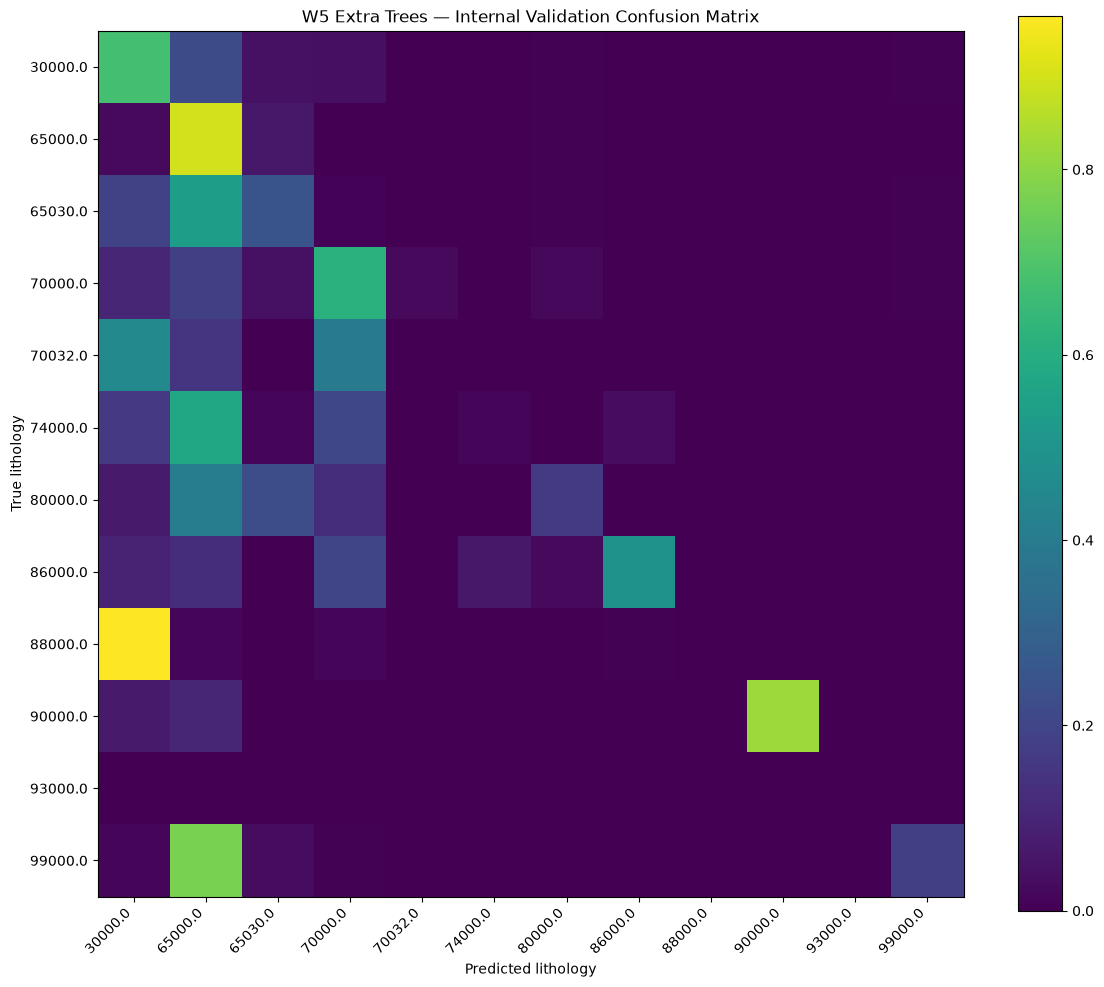

In [21]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

all_labels_internal = np.arange(12)

cm_internal = confusion_matrix(
    y_internal_val_encoded,
    y_pred_internal,
    labels=all_labels_internal
)

row_totals = cm_internal.sum(axis=1, keepdims=True)

cm_internal_norm = np.divide(
    cm_internal,
    row_totals,
    out=np.zeros_like(cm_internal, dtype=float),
    where=row_totals != 0
)

print("Normalized confusion matrix:")
print(np.round(cm_internal_norm, 3))

plt.figure(figsize=(12, 10))
plt.imshow(cm_internal_norm, interpolation="nearest")
plt.colorbar()

plt.xticks(
    all_labels_internal,
    label_encoder_internal.classes_,
    rotation=45,
    ha="right"
)
plt.yticks(
    all_labels_internal,
    label_encoder_internal.classes_
)

plt.xlabel("Predicted lithology")
plt.ylabel("True lithology")
plt.title("W5 Extra Trees — Internal Validation Confusion Matrix")

plt.tight_layout()
plt.show()

| True lithology | Correct | Main confusion |
|---|---:|---|
| Sandstone 30000 | 67.6% | → Shale 22.4% |
| Shale 65000 | **90.0%** | → Sandstone/Shale 6.4% |
| Sandstone/Shale 65030 | **25.2%** | → Shale 53.7% |
| Limestone 70000 | **61.6%** | → Sandstone 10.5%, Shale 18.2% |
| Chalk 70032 | **0%** | → Sandstone 45.4%, Limestone 39.7% |
| Dolomite 74000 | **1.6%** | → Shale 57.8%, Limestone 20.4% |
| Marl 80000 | **16.3%** | → Shale 40.9%, Sandstone/Shale 22.9% |
| Anhydrite 86000 | **49.6%** | → Limestone 20.0% |
| Halite 88000 | **0%** | → Sandstone 96.5% |
| Coal 90000 | **82.5%** | → Shale 10.5% |
| Basement 93000 | — | No validation samples |
| Tuff 99000 | **18.2%** | → Shale 76.9% |

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_internal_val_encoded,
        y_pred_internal,
        labels=np.arange(len(classes_internal)),
        target_names=[str(x) for x in classes_internal],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.60      0.68      0.64     38013
           1       0.83      0.90      0.86    176301
           2       0.32      0.25      0.28     29339
           3       0.61      0.62      0.61     12431
           4       0.00      0.00      0.00      2575
           5       0.10      0.02      0.03       495
           6       0.55      0.16      0.25     10947
           7       0.60      0.50      0.54       240
           8       0.00      0.00      0.00      3899
           9       0.49      0.82      0.62       514
          10       0.00      0.00      0.00         0
          11       0.29      0.18      0.22      1838

    accuracy                           0.73    276592
   macro avg       0.37      0.34      0.34    276592
weighted avg       0.70      0.73      0.71    276592



decision?

| Class | Internal F1 | PUBLIC F1 | Interpretation |
|---|---:|---:|---|
| Sandstone | 0.64 | ~0.77 | Good |
| Shale | **0.86** | ~0.68 | Strong |
| Sandstone/Shale | **0.28** | ~0.36 | Difficult |
| Limestone | **0.61** | ~0.49 | Reasonable |
| Chalk | 0.00 | ~0.26 | Very difficult |
| Dolomite | 0.03 | ~0.06 | Very difficult |
| Marl | 0.25 | ~0.16 | Difficult |
| Anhydrite | 0.54 | ~0.43 | Reasonable |
| Halite | 0.00 | 0.00 | Not learned |
| Coal | **0.62** | ~0.48 | Good |
| Basement | — | 0.00 | Insufficient samples |
| Tuff | 0.22 | ~0.11 | Difficult |